In [2]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [2]:
from seaborn import cm

: 

In [3]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

: 

In [4]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

: 

In [1]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "german_credit"
dt_name = "toy_dataset"

cf_method = 'ils'#dice or 'debug'


name_dataset = {"german_credit": "German Credit", 
                "adult": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

NameError: name 'utl' is not defined

In [6]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/toy_dataset/feature_names.csv
Loaded X_train from data/processed/toy_dataset/X_train.npz
Loaded y_train from data/processed/toy_dataset/y_train.npz
Loaded X_test from data/processed/toy_dataset/X_test.npz
Loaded y_test from data/processed/toy_dataset/y_test.npz
Loaded X_calibration from data/processed/toy_dataset/X_calibration.npz
Loaded y_calibration from data/processed/toy_dataset/y_calibration.npz


In [7]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for toy_dataset
Loaded random_forest model from models/toy_dataset/random_forest.pkl
Loaded existing random_forest model
Processing mlp for toy_dataset
Loaded mlp model from models/toy_dataset/mlp.pkl
Loaded existing mlp model
Processing xgboost for toy_dataset
Loaded xgboost model from models/toy_dataset/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for toy_dataset
Loaded lgbm model from models/toy_dataset/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [8]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    utl.plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.97
Model random_forest Accuracy: 0.92
Model random_forest F1 Score: 0.92
Model random_forest Balanced Accuracy: 0.92
■ 
 ■

Model mlp ROC AUC: 0.98
Model mlp Accuracy: 0.91
Model mlp F1 Score: 0.91
Model mlp Balanced Accuracy: 0.91
■ 
 ■

Model xgboost ROC AUC: 0.97
Model xgboost Accuracy: 0.93
Model xgboost F1 Score: 0.93
Model xgboost Balanced Accuracy: 0.93
■ 
 ■

Model lgbm ROC AUC: 0.97
Model lgbm Accuracy: 0.94
Model lgbm F1 Score: 0.94
Model lgbm Balanced Accuracy: 0.94
■ 
 ■



In [9]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [10]:
np.random.randint(0,7), np.random.rand()*7

(0, 3.516864218837624)

In [11]:

                 
import pickle

#with open("debug/ranking_new_t.pkl", "rb") as f:
#    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


### The distances took into account

In [12]:
from src.distances import get_distances
metrics = ["l0", "l1", "l2", "inf", "-inf", "sqeuclidean", "mae", "cosine", "correlation", "chebyshev", "minkowski", "canberra", "braycurtis", "hamming", "jaccard", "wasserstein", "spearman", "kendall", "centered_l2", "centered_cosine"]

In [13]:
'''
X = splits['X_test'].values[:10]

x = splits['X_test'].values[0]

print("Distance examples:")
for metric in metrics:
        distances = get_distances(X,x, policy=metric)
        #print(f"{metric} : {[f'{d:.2f}' for d in distances]}")
        plt.plot(distances, label=metric)
plt.legend()
plt.show()
'''

'\nX = splits[\'X_test\'].values[:10]\n\nx = splits[\'X_test\'].values[0]\n\nprint("Distance examples:")\nfor metric in metrics:\n        distances = get_distances(X,x, policy=metric)\n        #print(f"{metric} : {[f\'{d:.2f}\' for d in distances]}")\n        plt.plot(distances, label=metric)\nplt.legend()\nplt.show()\n'

In [19]:
all_stats = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}




In [63]:
all_stats_test = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}


In [64]:
fname = os.path.join(cf_method,dt_name+"_ranking_latent.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test_latent.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


Loaded ils/toy_dataset_ranking_latent.pkl
!!!!!! ils/toy_dataset_ranking_test_latent.pkl not found


In [3]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

NameError: name 'all_stats' is not defined

In [66]:
compute_test = True

In [67]:
all_stats_tmp = all_stats_test if compute_test else all_stats
def select_test (x):return "test" in x if compute_test else ("test" not in x)

In [68]:
select_test("test"), select_test("train")

(True, False)

In [69]:
import src.cf_generator_ils as cfils

cf_generator = cfils.IlsCFGenerator(config=config,
                                    dataset_name=dt_name,
                                    )
reference_set = splits['X_train'].copy()
feat_names = splits['X_train'].columns.to_list()
target_name = data_processor.target_name
# we add the target variable to the reference set
reference_set[target_name] = splits['y_train']
cf_generator.setup(
    reference_data=reference_set,
    #feature_names=feat_names,
    continuous_features = feat_names,
    categorical_features=[],#data_processor.categorical_features,
    target_name=target_name,
    )

X_calibration=splits['X_calibration'][:].copy()
y_calibration=splits['y_calibration'][:].copy()

for model_name, model in models.items():
    cf_generator._setup_model_components(model, model_name, X_calibration, y_calibration)
    latent = cf_generator._explainers[model_name]

trying to load explainer model from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_random_forest_Ls_2.pkl
Loaded component from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_random_forest_Ls_2.pkl
Explainer model found. Loading existing ILS.
Explainer model loaded.
trying to load explainer model from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_mlp_Ls_2.pkl
Loaded component from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_mlp_Ls_2.pkl
Explainer model found. Loading existing ILS.
Explainer model loaded.
trying to load explainer model from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_xgboost_Ls_2.pkl
Loaded component from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_xgboost_Ls_2.pkl
Explainer model found. Loading existing ILS.
Explainer model loaded.
trying to load explainer model from counterfactuals/cf_generators/ils/ils_explainer_toy_dataset_lgbm_Ls_2.pkl
Loaded component from counterfactuals/cf_ge

## Compute the distances 
Counterfactual should be already present

In [70]:



start = time.time()
for jj,k in enumerate(tqdm(models.keys())):
    not_found = 0
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file). The value of "cfs" is a np array of dictionaries. The keys of the dictionaries are:, instace_idx (the index of the instance in the calibration set), original_instance (the original class of the instance), true_class (the true class of the instance)
    print(cfs["cfs"].shape[0])
    if check_res(stats_dict=all_stats_tmp,k=k):
        print("Already computed for model",k,end=" elements:")
        print(len(all_stats_tmp[k]['distances']['l2']['mean']))

        continue
    else:
        print("Computing for model",k)
    probabs = []
    corrects = []
    confs = []
    # cfs = {"cfs":np.arange(200)}

    # I forgot to save the original instance projected in the latent space, so we have to reload the explainer
    # and project the original instance in the latent space
    latent = cf_generator._explainers[k]
    
    for i in tnrange(cfs["cfs"].shape[0]):
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        # original instance is not anymore the right one sadly... 
        # therefore we get the original instance from the dataset itself by using the "compute_test" flag and the  instance_idx attribute
        original_instance = splits[('X_test' if  compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1,-1)
        original_class = cfs["cfs"][i]["true_class"].values
        
        #true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        good_cfs = cfs["cfs"][i]["latent_counterfactuals"].values#[:,:-1]
        #good_cfs = good_cfs[true_cf != pred]
        true_cf = np.ones(len(good_cfs))#true_cf[true_cf != pred]
        if len (good_cfs) > 0:
            mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
        else:
            mean_confidences_cfs = np.array([np.nan,np.nan])
        for metric in metrics:
            if len(true_cf) == 0:
                distancies = np.array([np.inf])
                print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
                not_found+=1
            else:
                assert (true_cf-true_cf.mean() == 0).all(), "The counterfactuals are not aligned with the target"+str(true_cf)
                #distancies = np.linalg.norm(good_cfs - cfs["cfs"][i]["original_instance"].values,axis=1)
                _,original_instance_transformed = latent.transform(original_instance)
                
                distancies = get_distances(good_cfs, original_instance_transformed,
                                        policy=metric)
            
            all_stats_tmp[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats_tmp[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats_tmp[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats_tmp[k]['distances'][metric]['std'].append(distancies.std(axis=0))
            
        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)
        # print(distancies)
        #if i / 4 < 1:
        #   sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])
    all_stats_tmp[k]['probabs'] = probabs
    all_stats_tmp[k]['corrects'] = corrects
    all_stats_tmp[k]['mean_conf'] = confs
    print("For the model ",k,"not found",not_found,"counterfactuals")


  0%|          | 0/4 [00:00<?, ?it/s]

looking into the folder  counterfactuals/random_forest/toy_dataset
I found 1 files
for model random_forest using file cf_results_ils_random_test_20250209_222949.npz
checking cf_results_ils_random_test_20250209_222949.npz
250
(0 elements computed)
Computing for model random_forest


  0%|          | 0/250 [00:00<?, ?it/s]

For the model  random_forest not found 0 counterfactuals
looking into the folder  counterfactuals/mlp/toy_dataset
I found 1 files
for model mlp using file cf_results_ils_random_test_20250209_222953.npz
checking cf_results_ils_random_test_20250209_222953.npz
250
(0 elements computed)
Computing for model mlp


  0%|          | 0/250 [00:00<?, ?it/s]

For the model  mlp not found 0 counterfactuals
looking into the folder  counterfactuals/xgboost/toy_dataset
I found 1 files
for model xgboost using file cf_results_ils_random_test_20250209_222958.npz
checking cf_results_ils_random_test_20250209_222958.npz
250
(0 elements computed)
Computing for model xgboost


  0%|          | 0/250 [00:00<?, ?it/s]

For the model  xgboost not found 0 counterfactuals
looking into the folder  counterfactuals/lgbm/toy_dataset
I found 1 files
for model lgbm using file cf_results_ils_random_test_20250209_223004.npz
checking cf_results_ils_random_test_20250209_223004.npz
250
(0 elements computed)
Computing for model lgbm


  0%|          | 0/250 [00:00<?, ?it/s]

For the model  lgbm not found 0 counterfactuals


In [71]:
fname,fname_test

('ils/toy_dataset_ranking_latent.pkl',
 'ils/toy_dataset_ranking_test_latent.pkl')

## Save files for the distances
if not already present

In [4]:
if compute_test:
    all_stats_test = all_stats_tmp
else:
    all_stats = all_stats_tmp
compute_test

NameError: name 'compute_test' is not defined

184
True True
181
True True
184
True True
179
True True


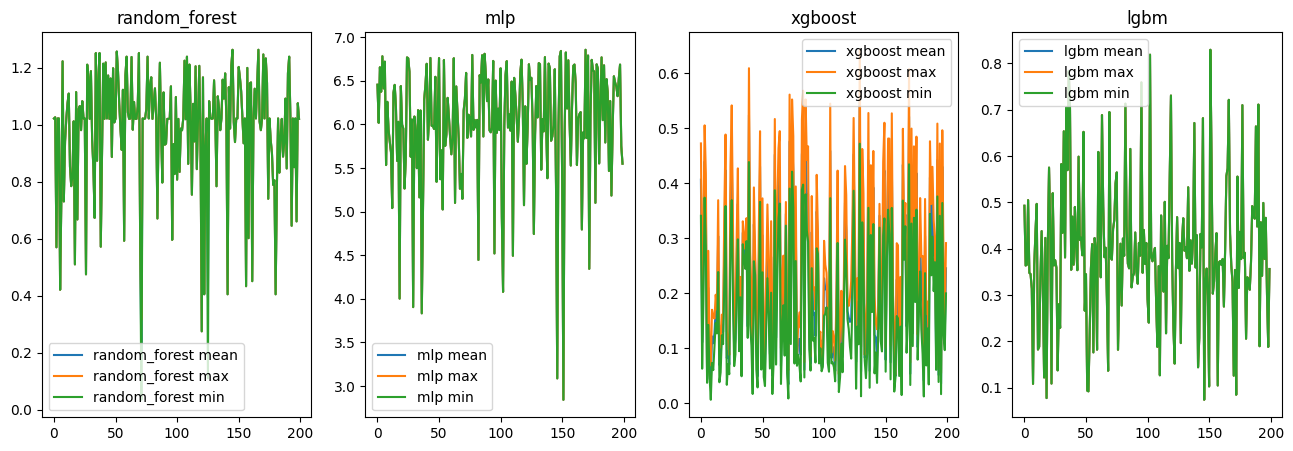

In [73]:
# to check plot the distances of the l0 metric for all the models
# use four subplots
fig, axs = plt.subplots(1,4,figsize=(16,5))
axs = axs.flatten()
for jj,k in enumerate(models.keys()):
    axs[jj].plot(all_stats[k]['distances']['l2']['mean'],label=k+" mean")
    axs[jj].plot(all_stats[k]['distances']['l2']['max'],label=k+" max")
    axs[jj].plot(all_stats[k]['distances']['l2']['min'],label=k+" min")
    # check the correct list
    
    print(np.array(all_stats[k]['corrects']).sum())
    print(0.0==0,1.0==1)

    # set the legend and the title
    axs[jj].legend()
    axs[jj].set_title(k)
    

In [42]:
'''# I did an error and I have to remove the the whole list of distances for the model random_forest
# I will "re initialize" the list of distances for the model random_forest
for k in ["random_forest"]:
    all_stats[k]['distances'] = {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per samplea
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        }'''

In [75]:
# check how many distancies are computed, i fear that I have confused the test and calibration set
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [76]:
fname

'ils/toy_dataset_ranking_latent.pkl'

In [77]:

if not utl.check_file_exists(fname):
    with open(fname, "wb") as f:
        pickle.dump(all_stats, f)
        print("dumped",fname)
else:
    print("File already exists",fname)

File already exists ils/toy_dataset_ranking_latent.pkl


In [78]:
fname_test

'ils/toy_dataset_ranking_test_latent.pkl'

In [79]:

if not utl.check_file_exists(fname_test):
    with open(fname_test, "wb") as f:
        pickle.dump(all_stats_test, f)
        print("dumped",fname_test)
else:
    print("File already exists",fname_test)


dumped ils/toy_dataset_ranking_test_latent.pkl


In [80]:

# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in metrics:
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats[k]['distances'][metric][stat] = np.array(all_stats[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats[k]['distances'][metric][stat]))
                for e in all_stats[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats[k]['probabs'] = np.array(all_stats[k]['probabs'])
    all_stats[k]['corrects'] = np.array(all_stats[k]['corrects']).reshape(-1)
    all_stats[k]['mean_conf'] = np.array(all_stats[k]['mean_conf'])

In [81]:
# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in metrics:
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats_test[k]['distances'][metric][stat] = np.array(all_stats_test[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats_test[k]['distances'][metric][stat]))
                for e in all_stats_test[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats_test[k]['probabs'] = np.array(all_stats_test[k]['probabs'])
    all_stats_test[k]['corrects'] = np.array(all_stats_test[k]['corrects']).reshape(-1)
    all_stats_test[k]['mean_conf'] = np.array(all_stats_test[k]['mean_conf'])

## There is a correlation?
Let's see the correlation between the distances (min, max, mean) and theprobability output of the model.


In [82]:
compute_test# = False

True

[0.         0.04761905 0.0952381  0.14285714 0.19047619 0.23809524
 0.28571429 0.33333333 0.38095238 0.42857143 0.47619048 0.52380952
 0.57142857 0.61904762 0.66666667 0.71428571 0.76190476 0.80952381
 0.85714286 0.9047619  0.95238095 1.        ]


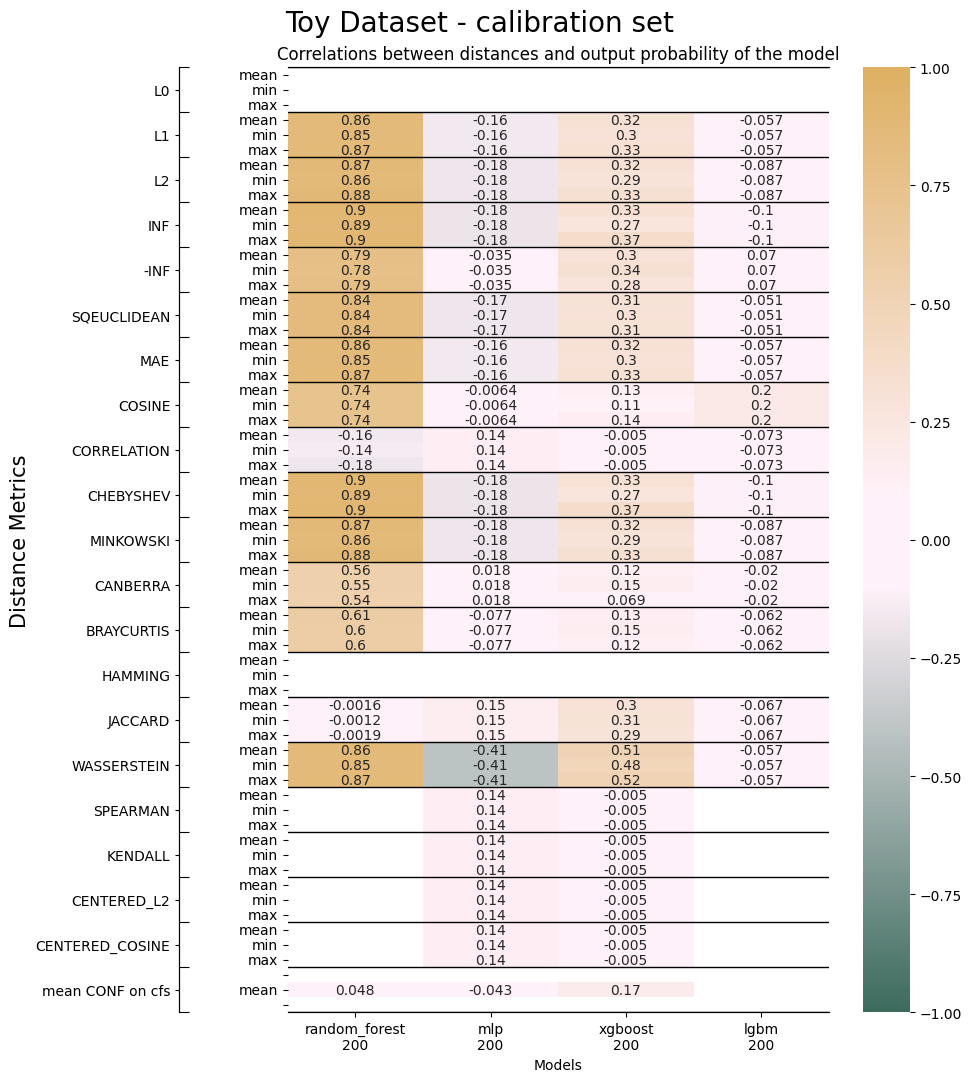

[0.         0.04761905 0.0952381  0.14285714 0.19047619 0.23809524
 0.28571429 0.33333333 0.38095238 0.42857143 0.47619048 0.52380952
 0.57142857 0.61904762 0.66666667 0.71428571 0.76190476 0.80952381
 0.85714286 0.9047619  0.95238095 1.        ]


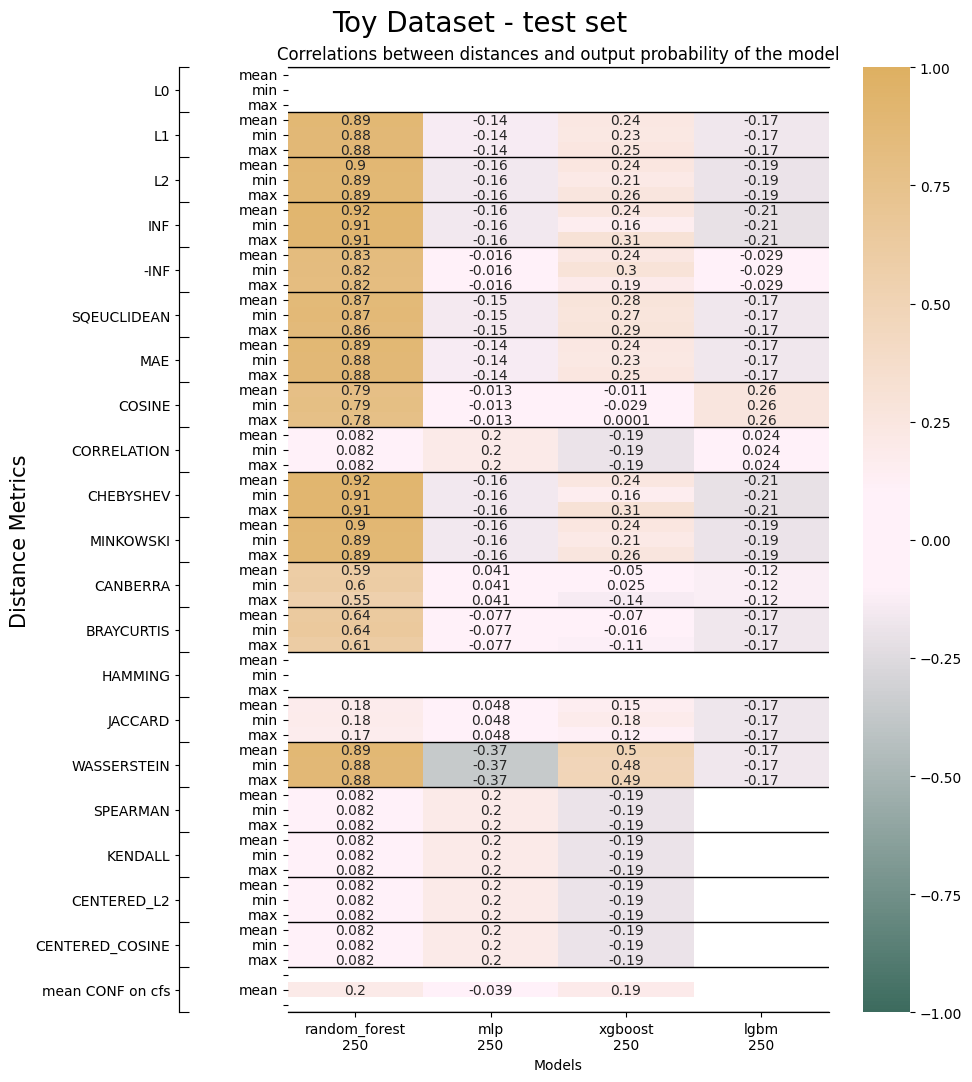

In [85]:

from matplotlib import ticker
    # Convert lists to numpy arrays first
for compute_test in [False,True]:
    all_stats_tmp = all_stats_test if compute_test else all_stats
    verbose = False
    correlations = {}
    for metric in metrics:
        correlations[metric] = {}
        correlations["found_cfs"]={}
        for k in models.keys():
            
            mins  = all_stats_tmp[k]['distances'][metric]['min'][:]
            good_idxs = mins != np.inf

            mins = mins[good_idxs]
            maxs  = all_stats_tmp[k]['distances'][metric]['max'][:][good_idxs]
            means = all_stats_tmp[k]['distances'][metric]['mean'][:][good_idxs]
            probs = all_stats_tmp[k]['probabs'][:][good_idxs]
            if good_idxs.sum() == 0:
                print("No counterfactuals found for model",k,"and metric",metric)
                correlations[metric][k] = {"min":np.nan,"max":np.nan,"mean":np.nan}
                correlations["found_cfs"][k] = 0
                continue
            correlations[metric][k] = {}
            
            
            correlations[metric][k]["min"] = np.corrcoef(mins, probs.max(axis=1))[0,1]
            
            correlations[metric][k]["max"] = np.corrcoef(maxs, probs.max(axis=1))[0,1]
            correlations[metric][k]["mean"] = np.corrcoef(means, probs.max(axis=1))[0,1]
            if verbose:
                print(f"{metric} correlation for {k}:")
                print("Min", np.round(correlations[metric][k]["min"],3))
                print("Max", np.round(correlations[metric][k]["max"],3))
                print("Mean", np.round(correlations[metric][k]["mean"],3))
                print()
            correlations["found_cfs"][k] = good_idxs.sum()

    # lastly for each model let's compare the confidence of the model (probabs) with the mean confidence of the counterfactuals
    correlations["mean_conf"] = {}
    for k in models.keys():
        good_idx = all_stats_tmp[k]['distances']['l2']['min'] != np.inf
        if good_idx.sum() == 0:
            correlations["mean_conf"][k] = np.nan
        else:
            correlations["mean_conf"][k] = np.corrcoef(all_stats_tmp[k]['mean_conf'][good_idx[:]].max(axis=1), all_stats_tmp[k]['probabs'][good_idx[:]].max(axis=1))[0,1]

    # Create a bigger matrix for all metrics
    # Shape will be (3 * number_of_metrics, number_of_models)
    all_correlations = []
    for metric in metrics:
        metric_corr = []
        for stat in ["mean", "min", "max"]:
            row = [correlations[metric][model][stat] for model in models.keys()]
            metric_corr.append(row)
        all_correlations.extend(metric_corr)

    all_correlations.append([np.nan for model in models.keys()])
    all_correlations.append([correlations["mean_conf"][model] for model in models.keys()])
    all_correlations.append([np.nan for model in models.keys()])

    all_correlations = np.array(all_correlations)

    # Create labels for y-axis that include both metric and stat
    y_labels = []
    for metric in metrics:
        for stat in ["mean", "min", "max"]:
            y_labels.append(f"{stat}")
    y_labels.append("")
    y_labels.append("mean")
    y_labels.append("")
    total_metrics = len(metrics)+1
    rows_per_metric = 3

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, len(metrics)*0.55))
    gold_map_r = fplt.build_cmap(0.1, '#3c6b5e', '#fff1f9', '#deb062')
    sns.heatmap(all_correlations, annot=True, ax=ax, vmin=-1, vmax=1, cmap=gold_map_r)
    ax.set_yticks(0.5+np.arange(len(y_labels)),y_labels, rotation=0)
    ax.set_xticklabels([model+"\n"+str(correlations["found_cfs"][model]) for model in models.keys()])
    ax.set_title("Correlations between distances and output probability of the model")
    #plt.ylabel("Distance Metrics")
    plt.xlabel("Models")
    # Add horizontal lines between metric sections
    for i in range(total_metrics + 1):
        ax.axhline(y=i*rows_per_metric, color='black', linewidth=1)

    # Those are the ticks for the metrics's names
    ax_metrics = ax.twinx()
    ax_metrics.spines["left"].set_position(("axes", -0.2))
    ax_metrics.tick_params('both', length=3, direction='out', which='major')
    ax_metrics.yaxis.set_ticks_position("left")
    ax_metrics.yaxis.set_label_position("left")

    # Set metric positions and labels
    metric_positions = [(i * 3 + 1.5) for i in range(len(metrics)+1)]  # Center of each metric section
    ax_metrics.set_ylim(ax.get_ylim())
    ax_metrics.set_yticks(metric_positions)
    ax_metrics.set_yticklabels([m.upper() for m in metrics]+["mean CONF on cfs"])
    ax_metrics.set_ylabel("Distance Metrics", rotation=90,fontsize=15)

    # get anew axis
    ax_ = ax.twinx()
    ax_.spines["left"].set_position(("axes", -.2))

    ax_.tick_params('both', length=7, direction='in', which='major')
    ax_.yaxis.set_ticks_position("left")
    #ax_.yaxis.set_ticks_position("right")
    #ax_.yaxis.set_label_position("right")
    ticks_positions = (3*np.arange(0, len(metrics)+2))
    ticks_positions=ticks_positions/ticks_positions.max()
    print(ticks_positions)
    ax_.set_yticks(ticks_positions)
    ax_.set_yticklabels([""]*len(metrics)+[""]*2)

    ax_.spines["right"].set_visible(False)
    ax_metrics.spines["right"].set_visible(False)
    plt.suptitle(name_dataset+" - "+("test set" if compute_test else "calibration set"), fontsize=20)
    plt.tight_layout()
    # save the figure
    fig_name = os.path.join("plots",dt_name,
                            "Correlations_"+dt_name+"_"+("test" if compute_test else "cal")+"_"+cf_method+"_latent.pdf")
                            
    #plt.savefig(fig_name)
    #plt.savefig(fig_name.replace(".pdf",".png"))
    if True:#not compute_test:
        plt.show()
    else:
        plt.close(fig)

Text(0.5, 1.0, 'Max absolute correlation for each metric for Toy Dataset')

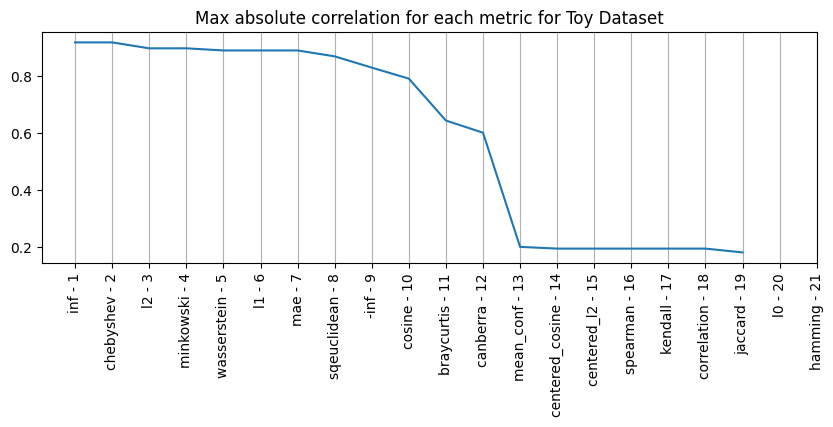

In [93]:
# choose the metric to plot
# for each metric take the max correlation amongthe min, mean and max for all the models
max_correlations = []

for j,m in enumerate(metrics):
    mmax = max([ abs(correlations[m][model]["min"]) for model in models.keys()] )
    mmean = max([abs(correlations[m][model]["mean"]) for model in models.keys()])
    Mmax = max([ abs(correlations[m][model]["max"]) for model in models.keys()] )
    # if any of the three is nan, place the -inf
    if np.isnan(mmax) or np.isnan(mmean) or np.isnan(Mmax):
        max_correlations.append((j,-np.inf))
    else:
        max_correlations.append((j,max([mmax,mmean,Mmax])))
max_correlations.append((j+1,max([abs(correlations["mean_conf"][model]) for model in models.keys()])))
max_correlations = np.array(sorted(max_correlations,key=lambda x: x[1],reverse=True))
np.array(metrics+["mean_conf"])[max_correlations[:,0].astype(int)]
#max_correlations[:5]
# make the plot very short
plt.figure(figsize=(10,3))

plt.plot(max_correlations[:,1])
plt.xticks(range(len(max_correlations)),[m+" - " + str(j+1) for j,m in  enumerate(np.array(metrics+["mean_conf"])[max_correlations[:,0].astype(int)])],rotation=90)
plt.grid(axis='x')
max_correlations
plt.title("Max absolute correlation for each metric for "+name_dataset)



In [94]:
top_metrics = 8

focus_metrics = np.array(metrics+["mean_conf"])[max_correlations[:top_metrics,0].astype(int)]
focus_metrics = [fm for fm in focus_metrics if fm != "mean_conf"]

focus_metrics

['inf',
 'chebyshev',
 'l2',
 'minkowski',
 'wasserstein',
 'l1',
 'mae',
 'sqeuclidean']

In [95]:
#get the unbalancing
v,c = utl.print_balancing(splits["y_calibration"])
class_w = np.array(
    [1-c[i]/c.sum() for i,v1 in enumerate(v)]
)

utl.print_balancing(splits["y_test"])
utl.print_balancing(splits["y_train"])


Balancing: 200 samples
|██████████          | class 0: 100 (50.0%)
|          ██████████| class 1: 100 (50.0%)

Balancing: 250 samples
|██████████          | class 0: 125 (50.0%)
|          ██████████| class 1: 125 (50.0%)

Balancing: 550 samples
|██████████          | class 0: 275 (50.0%)
|          ██████████| class 1: 275 (50.0%)



(array([0, 1]), array([275, 275]))

In [96]:
# let's seek the outliers (if any) by using the iforest algorithm
from sklearn.ensemble import IsolationForest
anomaly_detector = IsolationForest(contamination=0.05,random_state=42)

anomaly_detector.fit(splits["X_train"])#,sample_weight=class_w[splits["y_train"]])
anomalies = anomaly_detector.predict(splits["X_calibration"])<0
print("Found",anomalies.sum(),"anomalies")

anomaly_detector2 = IsolationForest(contamination=0.05,random_state=42)
anomaly_detector2.fit(splits["X_train"],sample_weight=class_w[splits["y_train"]].reshape(-1))
anomalies2 = anomaly_detector2.predict(splits["X_calibration"])<0
print("Found",anomalies2.sum(),"anomalies with class weights")
anomalies_test = anomaly_detector.predict(splits["X_test"])<0
print("Found",anomalies_test.sum(),"anomalies in the test set")




Found 12 anomalies
Found 12 anomalies with class weights
Found 22 anomalies in the test set


max 6.755743 min 0.0060885698 max_ylim 8.983128943443297 min_ylim -0.05


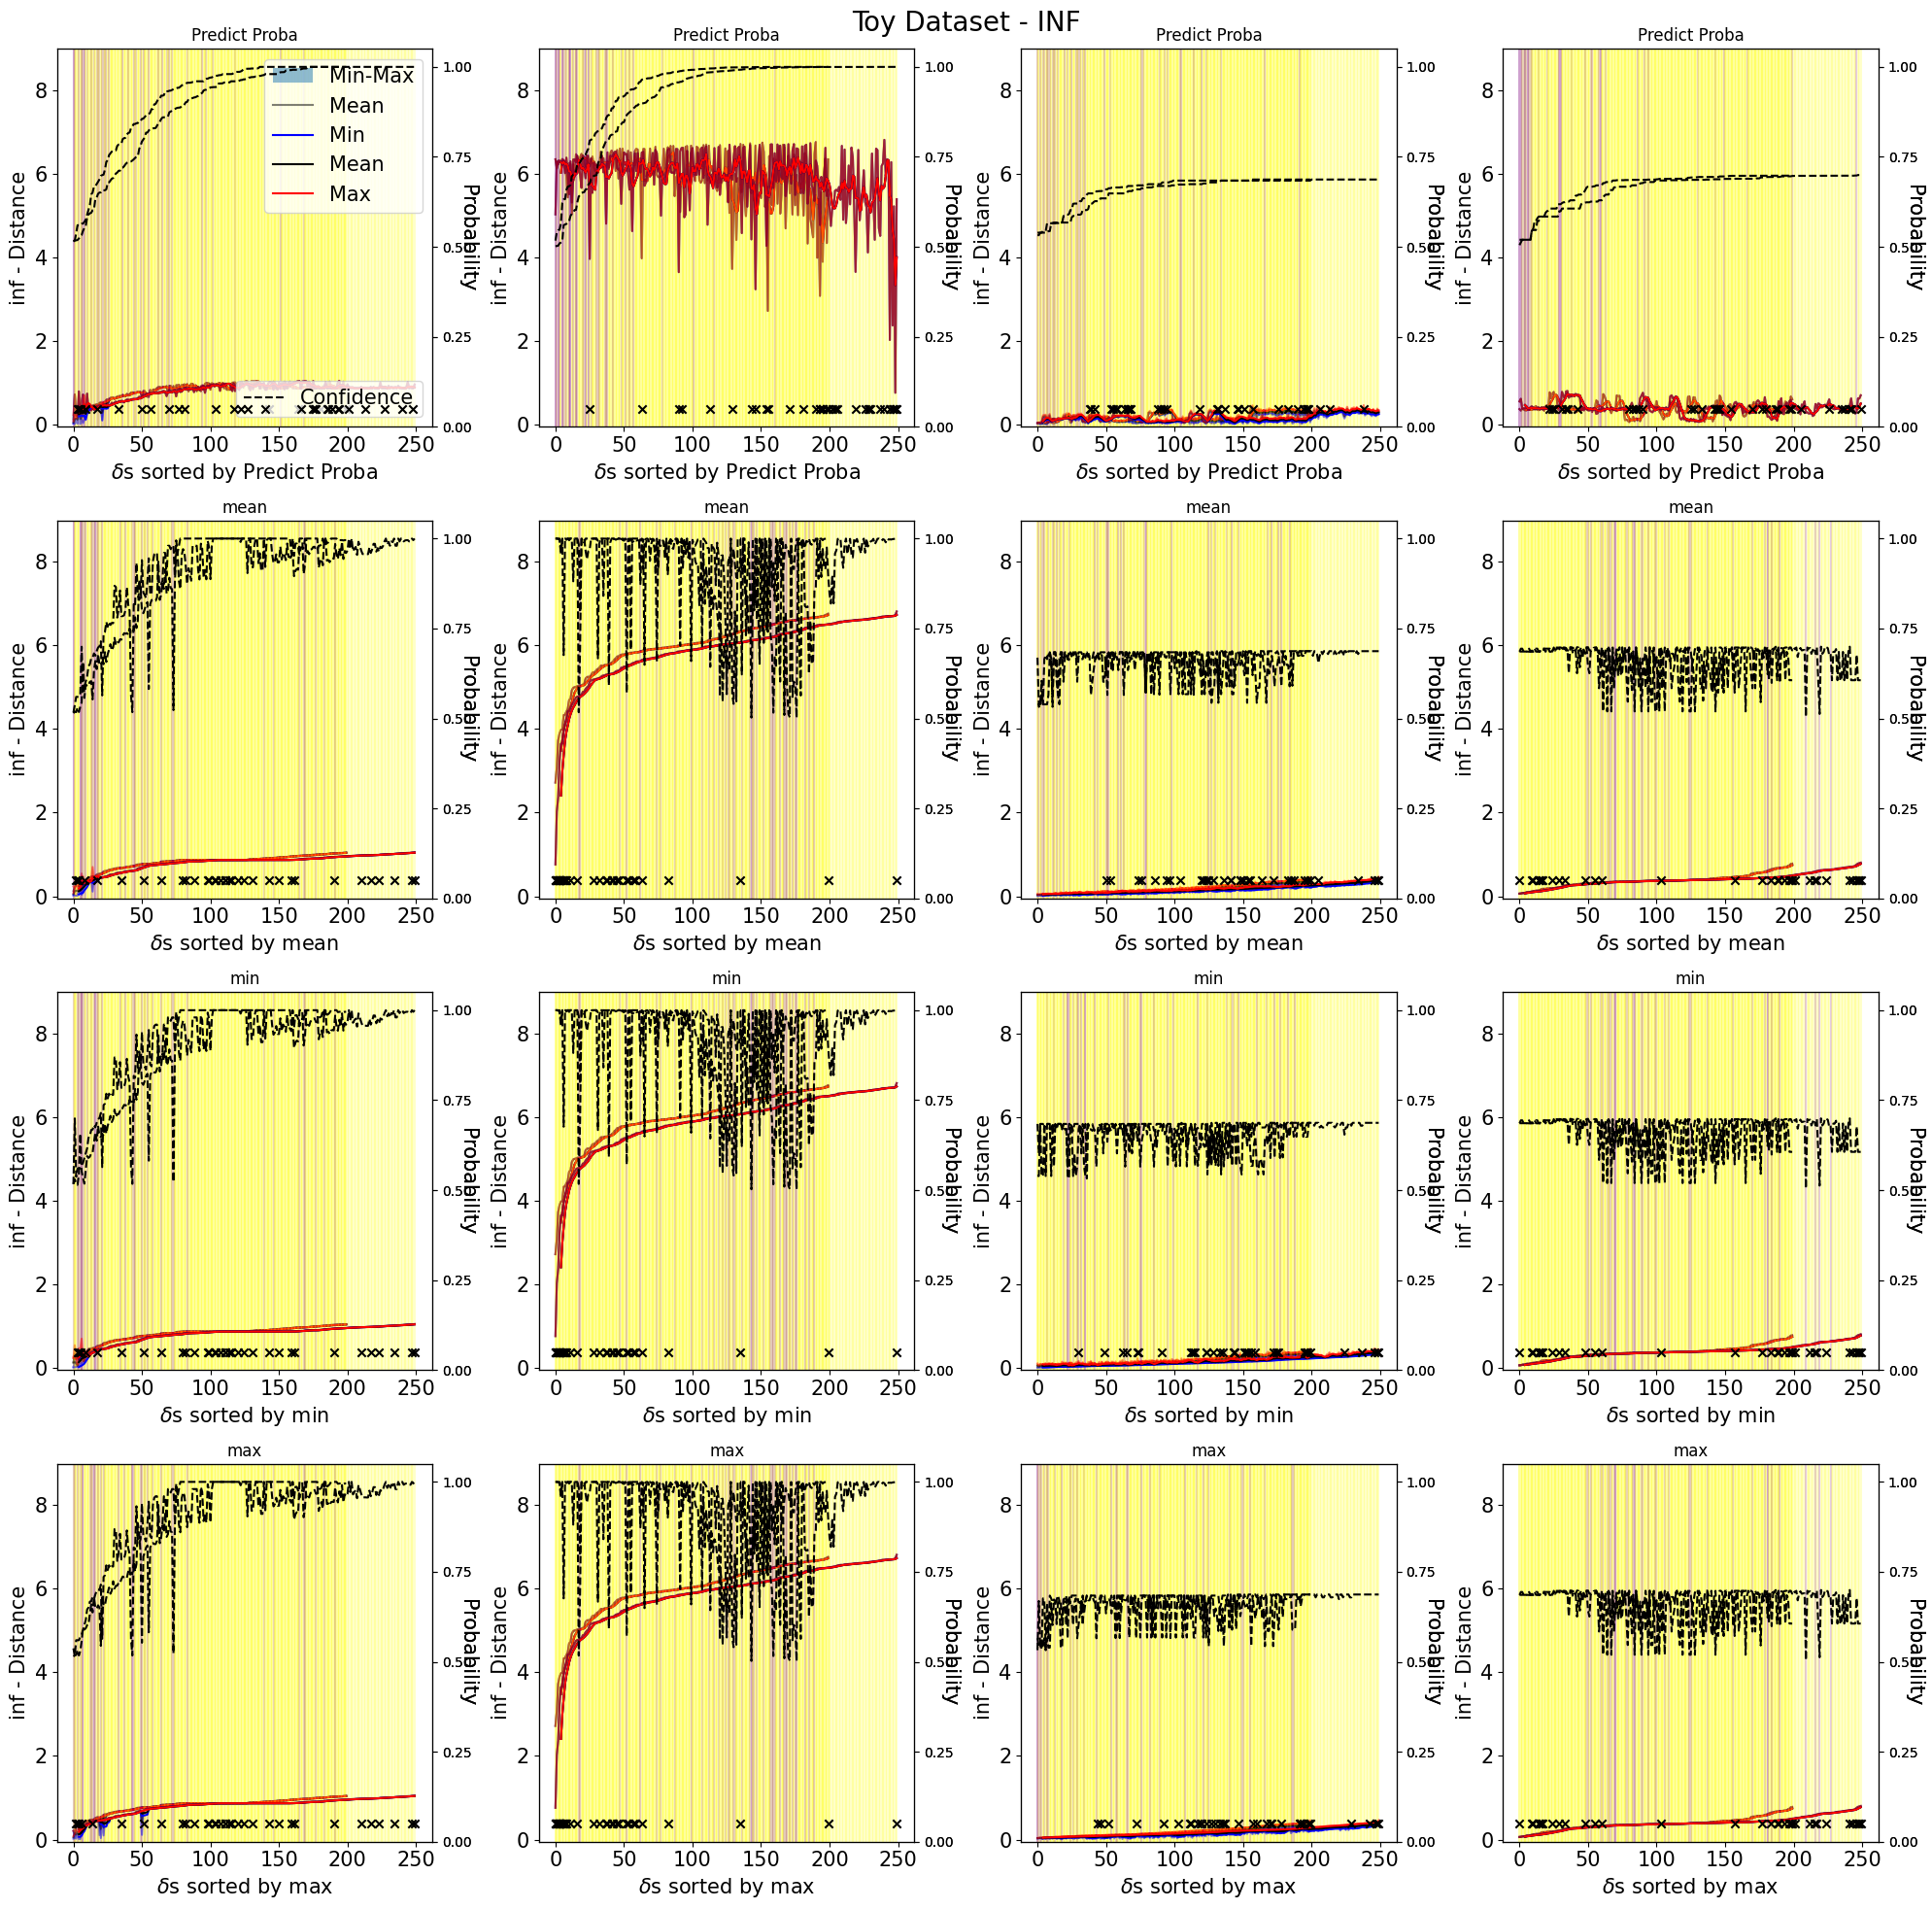

In [97]:
# now the plots!
# create 4 subplots
colors = {"min":"blue","max":"red","mean":"black"}
def create_plot_distances(dictionary,
                          metric = "l2",
                          sortby="mean",
                          axe=None,
                          title=None,
                          legend=False,colors = colors,
                          ylim = None):
    if axe == None:
        axe = plt.gca()

    min_color = colors["min"]
    max_color = colors["max"]
    mean_color = colors["mean"]

    argsorted = dictionary[sortby].argsort()
    rank_m = dictionary["min"][argsorted]
    rank_M = dictionary["max"][argsorted]
    rank_mean = dictionary["mean"][argsorted]
    
    if "correct" in dictionary.keys():
        rank_corrects = dictionary["correct"][argsorted]

        # shade the background with vertical lines colored by the corrects
        # if the model is correct the line is green, otherwise it's red
        # the alpha is 0.2, use axvline to plot the vertical lines
        for i in range(len(rank_corrects)):
            if rank_corrects[i]:
                axe.axvline(i,color="yellow",alpha=0.2)
            else:
                axe.axvline(i,color="purple",alpha=0.2)
        

    axe.fill_between(np.arange(len(rank_m)),rank_m,rank_M,alpha=0.5,label="Min-Max")
    axe.plot(rank_m,alpha=0.5,color=min_color)
    axe.plot(rank_mean,label="Mean",alpha=0.5,color=mean_color)
    axe.plot(rank_M,alpha=0.5,color=max_color)
    #axe.errorbar(np.arange(len(rank_m)),rank_mean,yerr=rank_std,label="Std")
    # plot the "smoothed" values
    axe.plot(np.arange(len(rank_m)),pd.Series(rank_m).rolling(5).mean(),label="Min",color=min_color)
    axe.plot(np.arange(len(rank_mean)),pd.Series(rank_mean).rolling(5).mean(),label="Mean",color=mean_color)
    axe.plot(np.arange(len(rank_M)),pd.Series(rank_M).rolling(5).mean(),label="Max",color=max_color)

    if legend:
        axe.legend(fontsize=15)
    axe.set_xlabel("$\delta$s sorted by "+sortby,fontsize=15)
    axe.set_ylabel(metric+" - Distance",fontsize=15)
    if title is not None:
        axe.set_title(title,fontsize=18)
    axe.grid()
    if ylim is not None:
        ylims = axe.get_ylim()

        axe.set_ylim(ylim[0],ylim[1])
        
    if "Predict Proba" in dictionary.keys():
        ax2 = axe.twinx()
        rank_prob = dictionary["Predict Proba"][argsorted]
        ax2.plot(np.arange(len(rank_m)),rank_prob,label="Confidence",color="black",linestyle="--")
        ax2.set_ylim(0,1.05)
        ax2.set_ylabel("Probability",fontsize=15,rotation=270)
        ax2.set_yticks(np.arange(0,1.1,0.25))
        if legend:
            # location is lower right
            ax2.legend(fontsize=15,loc="lower right")

        # get another x axes
    else:
        ax2 = axe.twiny()
        # place some ticks x shaped in correspondence of the anomalies
    if len(argsorted)== len(anomalies):
        ax2.scatter(np.arange(len(rank_m))[anomalies[argsorted]],
                 0.05*np.ones(anomalies.sum()),
                 marker="x",color="black",label="Anomalies")
    else:
        ax2.scatter(np.arange(len(rank_m))[anomalies_test[argsorted]],
                 0.05*np.ones(anomalies_test.sum()),
                 marker="x",color="black",label="Anomalies test")

    axe.set_title(sortby)
    five_perc = int(len(rank_m)*0.05)
    axe.set_xlim([-five_perc,len(rank_m)+five_perc])
    axe.xaxis.set_tick_params(labelsize=15)
    axe.yaxis.set_tick_params(labelsize=15)
    # tight layout
    plt.tight_layout()
    return axe


for metric in focus_metrics:
    fig, axs = plt.subplots(4, 4, figsize=(20, 20))
    axs = axs.flatten()
    # each model goes in a different subplot
    # we plot the sorted values of the minimum and the maximum distances,
    # then we shade the area between them. On top of that we plot the mean
    # at each data point we plot a vertical line with the std value of the distances, centeed at the mean
    c=0
    max_ = np.max([pd.Series(all_stats[k]["distances"][metric]["max"][
                   pd.Series(all_stats[k]["distances"][metric]["max"]).apply(np.isfinite)
                             ]).max(skipna=True)
                   for k in models.keys()])
    min_ = np.min([pd.Series(all_stats[k]["distances"][metric]["min"][
                   pd.Series(all_stats[k]["distances"][metric]["min"]).apply(np.isfinite)
                             ]).min(skipna=True)
                   for k in models.keys()])
    
    data_range = max_ - min_
    #make the the max_ylim so that the max value goes at the 67% of the plot
    max_ylim = max_ + (data_range * 0.33)  # Add 33% of range above max
    min_ylim = min_ - (data_range * 0.1)   # Subtract 10% of range below min
    min_ylim = max(-0.05,min_ylim)
    #max_ylim = min(20,max_ylim)
    #min_ylim = max(0,min_ylim)
    print("max",max_,"min",min_,"max_ylim",max_ylim,"min_ylim",min_ylim)
    for name in ["Predict Proba"]+["mean","min","max"]:
        for k in models.keys():
            create_plot_distances(dictionary={
                                    "mean":all_stats[k]["distances"][metric]["mean"],
                                    "std":all_stats[k] ["distances"][metric]["std"] ,
                                    "min":all_stats[k] ["distances"][metric]["min"] ,
                                    "max":all_stats[k] ["distances"][metric]["max"] ,
                                    "Predict Proba":all_stats[k]["probabs"].max(axis=1),
                                    "correct":all_stats[k]["corrects"]
                                    },
                            metric = metric,
                            sortby=name,
                            axe=axs[c],
                            title="model is "+k,
                            legend=(True if c==0 else False ),#%4== 0 else False),
                            ylim = (min_ylim,max_ylim))
            create_plot_distances(dictionary={
                                    "mean":all_stats_test[k]["distances"][metric]["mean"],
                                    "std":all_stats_test[k] ["distances"][metric]["std"],
                                    "min":all_stats_test[k] ["distances"][metric]["min"],
                                    "max":all_stats_test[k] ["distances"][metric]["max"],
                                    "Predict Proba":all_stats_test[k]["probabs"].max(axis=1),
                                    "correct":all_stats_test[k]["corrects"]
                                    },
                            metric = metric,
                            sortby=name,
                            axe=axs[c],
                            title="model is "+k,
                            legend=False,#%4== 0 else False),
                            ylim = (min_ylim,max_ylim))
            c+=1
    date = time.strftime("%Y-%m-%d")
    plt.suptitle(name_dataset+" - "+metric.upper(),fontsize=20)
    plt.tight_layout()
    #fig_name = os.path.join("plots",dt_name,
    #                        "counterfactuals_dice_"+dt_name+"_"+date+"_"+metric+".pdf")
    
    #plt.savefig(fig_name)
    #print("Saved Figure at ",fig_name)
    if True:#metric == focus_metrics[-1]:
        plt.show()
    plt.close(fig)
    break

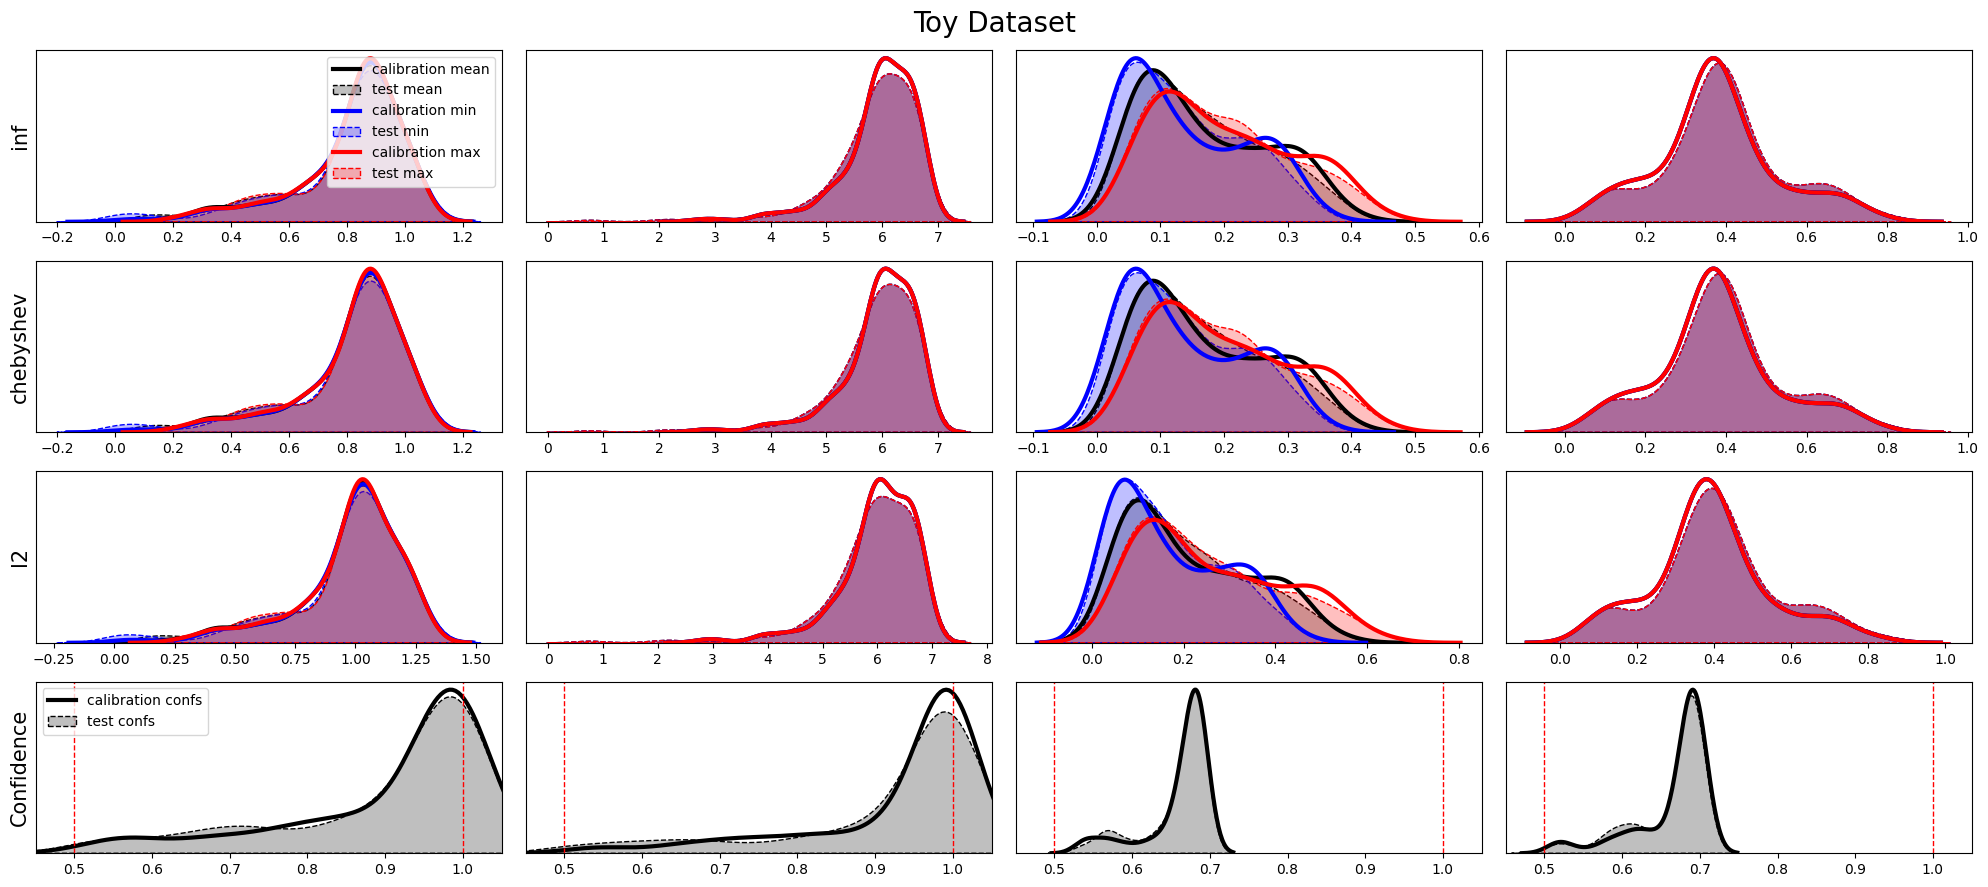

In [98]:
cumulative = False
top_k = 3
# colors = {"min":"blue","max":"red","mean":"black"}
fig, axs = plt.subplots(top_k+1,4, figsize=(20, 3*top_k))
axs = axs.flatten()
for i,metric in enumerate(focus_metrics[:top_k]):
    for name in ["mean","min","max"]:
        for j,k in enumerate(models.keys()):
            indx = 4*i+j
            # plot the distribution of the distances (calibration and test)
            sns.kdeplot(all_stats[k]["distances"][metric][name],ax=axs[indx],cumulative=cumulative,
                    label='calibration '+name,lw=3,color=colors[name])
            sns.kdeplot(all_stats_test[k]["distances"][metric][name],ax=axs[indx],cumulative=cumulative,
                    label='test '+name,ls="--",color=colors[name],fill=True)
    if i == 0:
        axs[0].legend(loc = "upper right")
    # remove the y ticks and the y labels
for j,ax in enumerate(axs):
    ax.yaxis.set_ticks([])
    ax.yaxis.set_ticklabels([])
    if j % 4 == 0 and j<=4*top_k:
        ax.yaxis.set_ticks_position("left")
        ax.yaxis.set_label_position("left")
        ax.set_ylabel(focus_metrics[j//4],fontsize=15)
        ax.yaxis.set_tick_params(labelsize=15)
    else:
        ax.set_ylabel("")
for indx,k in enumerate(models.keys()):
    indx+=4*top_k
    sns.kdeplot(all_stats[k]["probabs"].max(axis=1),ax=axs[indx],cumulative=cumulative,
                    label='calibration confs',lw=3,color="k")
    sns.kdeplot(all_stats_test[k]["probabs"].max(axis=1),ax=axs[indx],cumulative=cumulative,
                    label='test confs',ls="--",color='k',fill=True)
    axs[indx].set_xlim(0.45,1.05)
    # plot vertical lines at 0.5 and 1.0
    axs[indx].axvline(0.5,color="red",lw=1,ls='--')
    axs[indx].axvline(1.0,color="red",lw=1,ls='--')
    if indx % 4 == 0:
        axs[indx].legend(loc = "upper left")
        axs[indx].set_ylabel("Confidence",fontsize=15)
    
date = time.strftime("%Y-%m-%d")
plt.suptitle(name_dataset,fontsize=20)
plt.tight_layout()
fig_name = os.path.join("plots",dt_name,
                        "distributions"+dt_name+"_"+metric+".pdf")
plt.savefig(fig_name)
plt.show()       
plt.close(fig)
    

## NOW the rejection classifiers!
The rejection classifiers are trained on the distances [and the probability output of the model.]


In [99]:

#from Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss

from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
# use importlib as we have to reload the module
#importlib.reload(cfdr)
import rejectmodels.CFDistRejector as cfdr



In [100]:
# Selective Classifiers
# the keys are the models
plug_in_rulers = {}
selected_plg = {}

l2_rejectors = {}
l2_rejectors_gamma = {}

plug_in_rulers_auc = {}
selected_plg_auc = {}
selected_l2r = {}
selected_l2r_gamma = {}

# now let's generalize for all the l2r based on distaces:
# since for each metric we have 3 values (min, mean, max) we will have 3 different rejectors for each metric
# keeping a named dict for each is unfeasible, so we will use a dictionary of dictionaries:
# the key will be the metric followed by the type (min, mean, max) and the value will be a dictionary with the model as key.
#  l2rejectors_distances
l2_rejectors_distances = {}
selected_l2_rejectors_distances = {}

# the values are:
# - rejection_quality_dict: the rejection quality of the model
# - plug_in_rulers: the plug-in ruler of the models
# - rejected_by_coverage: the number of samples rejected by the coverage
# - classification_quality_dict: the classification quality of the model () 
rejected_by_coverage = {}
classification_quality_dict = {}
rejection_quality_dict = {}
included_samples = {}

all_original_scores = {}
# the target coverages
target_coverages_n = 30
target_coverages = np.linspace(0.001,1,target_coverages_n-6)[::-1][1:]
target_coverages = sorted(list(set(target_coverages))+[0.5,0.9,0.95,0.99,0.01,0.05],reverse=True)
target_coverages_n = len(target_coverages)
n = len(splits['X_test'])

# initialize the dictionaries for the results
for k in models.keys():
    # Our method
    l2_rejectors[k] = cfdr.CFDistRejector(model=models[k],
                                    coverages=target_coverages)
    
    l2_rejectors_gamma[k] = cfdr.CFDistRejector(model=models[k],coverages=target_coverages)
    # The others:
    # the plug-in ruler
    plug_in_rulers[k] =  PlugInRule(model=models[k])
    # Probably I will have to change this to the version that do not refit the model
    plug_in_rulers_auc[k] = PlugInRuleAUC(model=models[k])
    all_original_scores[k] = accuracy_score(splits['y_test'], models[k].predict(splits['X_test']))
    
    # the following are the dictionaries for the results, one for each selective technique
    rejected_by_coverage[k] = {}
    classification_quality_dict[k] = {}
    rejection_quality_dict[k] = {}
    included_samples[k] = {}
    for selective_c in ["PlugInRule","PlugInRuleAUC","CFDistRejector","CFDistRejector_gamma"]:
        rejected_by_coverage[k][selective_c] = np.zeros(target_coverages_n)
        classification_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
        rejection_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
        included_samples[k][selective_c] = np.zeros(target_coverages_n)


for k in models.keys():
    l2_rejectors_distances[k] = {}
    for metric in focus_metrics:
        for m_type in ["min","max","mean"]:
            selective_c = "CFDistRejector_"+metric+"_"+m_type
            l2_rejectors_distances[k][selective_c] = cfdr.CFDistRejector(model=models[k],
                                    coverages=target_coverages)
                                    #distance=metric,
                                    #distance_type=m_type)
            # the following are the dictionaries for the results, one for each selective technique
            rejected_by_coverage[k][selective_c] = np.zeros(target_coverages_n)
            classification_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
            rejection_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
            included_samples[k][selective_c] = np.zeros(target_coverages_n)

        

metric_dicts = {
    "rejected_by_coverage":rejected_by_coverage,
    "classification_quality_dict":classification_quality_dict,
    "rejection_quality_dict":rejection_quality_dict,
    "included_samples":included_samples
}    

In [101]:
included_samples["mlp"].keys()
selected_l2_rejectors_distances.keys()

dict_keys([])

In [102]:
from src.utils import compute_selective_metrics

In [103]:
for jj,k in enumerate(models.keys()):
    print("Model",k)
    ###########################
    ## SELECTIVE CLASSIFIERS ##
    ###########################
    # get the plug in rule
    plug_in_rule = plug_in_rulers[k]
    #target_coverages = [.99, .75, .50, ...] 
    plug_in_rule.calibrate(splits["X_calibration"], target_coverages=target_coverages)
    # here we create an array containing levels for acceptance depending on how the selective classifiers are calibrated
    # since we used 100 target coverages, we have 101 levels of acceptance, i.e., 0, 1, 2, 3, ..., 100
    selected_plg[k] = plug_in_rule.qband(splits["X_test"])

    
    
    plug_in_ruler_auc = plug_in_rulers_auc[k]
    # Here we calibrate the selective classifier that uses the AUC
    plug_in_ruler_auc.calibrate(X=splits["X_calibration"],
                                    y=splits["y_calibration"].values.reshape(-1),
                                    target_coverages=target_coverages)
    selected_plg_auc[k] = plug_in_rulers_auc[k].qband(splits["X_test"])

    # get the l2 rejector
    l2_rejector = l2_rejectors[k]
    # calibrate the rejector
    l2_rejector.calibrate(splits["X_calibration"], all_stats[k]["distances"]["l2"]["mean"])
    # save the selected data
    selected_l2r[k] = l2_rejector.qband(splits["X_test"],all_stats_test[k]["distances"]["l2"]["mean"])

    print(selected_plg[k][:10],type(selected_plg[k]))
    print(selected_plg_auc[k][:10],type(selected_plg_auc[k]))
    print(selected_l2r[k][:10],type(selected_l2r[k]))

    l2_rejectors_g = l2_rejectors_gamma[k]
    l2_rejectors_g.calibrate(splits["X_calibration"], all_stats[k]["distances"]["l2"]["mean"],
                             use_gamma=True)
    selected_l2r_gamma[k] = l2_rejectors_g.qband(splits["X_test"],all_stats_test[k]["distances"]["l2"]["mean"])




    for selective_k,selected in zip([
                                    "PlugInRule",
                                    "PlugInRuleAUC",
                                    "CFDistRejector",
                                    "CFDistRejector_gamma"
                                    ],
                                    [1,0,2,3]):
        if selective_k == "PlugInRuleAUC":
            selected = selected_plg_auc[k]
            selected_c = plug_in_rulers_auc[k]
        if selective_k == "PlugInRule":
            selected = selected_plg[k]
            selected_c = plug_in_rulers[k]
        if selective_k == "CFDistRejector":
            selected = selected_l2r[k]
            selected_c = l2_rejectors[k]
        if selective_k == "CFDistRejector_gamma":
            selected = selected_l2r_gamma[k]
            selected_c = l2_rejectors_g
        print(type(selected_c),type(selected))
        compute_selective_metrics(model_key=k,
                                    selected_data=selected,
                                    classifier_type=selective_k,
                                    selective_classifier=selected_c,
                                    splits=splits,
                                    target_coverages=target_coverages,
                                    n=n,
                                    metric_dicts=metric_dicts)
    # now we have to iterate over the metrics and the types of distances
    selected_l2_rejectors_distances[k] = {}
    for metric in focus_metrics:
        for m_type in ["min","max","mean"]:
            selective_c = "CFDistRejector_"+metric+"_"+m_type
            l2_rejector = l2_rejectors_distances[k][selective_c]
            l2_rejector.calibrate(splits["X_calibration"], all_stats[k]["distances"][metric][m_type])
            selected_l2_rejectors_distances[k][selective_c] = l2_rejector.qband(splits["X_test"],all_stats_test[k]["distances"][metric][m_type])
    for metric in focus_metrics:
        for m_type in ["min","max","mean"]:
            selective_c = "CFDistRejector_"+metric+"_"+m_type
            compute_selective_metrics(model_key=k,
                                    selected_data=selected_l2_rejectors_distances[k][selective_c],
                                    classifier_type=selective_c,
                                    selective_classifier=l2_rejectors_distances[k][selective_c],
                                    splits=splits,
                                    target_coverages=target_coverages,
                                    n=n,
                                    metric_dicts=metric_dicts)


Model random_forest
[29 12  9 12 29 29 15 18 17 29] <class 'numpy.ndarray'>
[14. 17.  6.  9. 14. 14. 11. 23. 20. 24.] <class 'numpy.ndarray'>
[18 23  6 23 18 18 24 27 10 13] <class 'numpy.ndarray'>
<class 'OLD_src.Lib.L2R.code.model_agnostic.PlugInRule'> <class 'numpy.ndarray'>
<class 'OLD_src.Lib.L2R.code.model_agnostic.PlugInRuleAUC'> <class 'numpy.ndarray'>
<class 'rejectmodels.CFDistRejector.CFDistRejector'> <class 'numpy.ndarray'>
<class 'rejectmodels.CFDistRejector.CFDistRejector'> <class 'numpy.ndarray'>
Model mlp
[17 23 11 16 14  9 11 14 21 20] <class 'numpy.ndarray'>
[13. 27.  9. 12. 11.  8.  9. 17. 25. 24.] <class 'numpy.ndarray'>
[22  3 22  2 25 23 23  8  7  5] <class 'numpy.ndarray'>
<class 'OLD_src.Lib.L2R.code.model_agnostic.PlugInRule'> <class 'numpy.ndarray'>
<class 'OLD_src.Lib.L2R.code.model_agnostic.PlugInRuleAUC'> <class 'numpy.ndarray'>
<class 'rejectmodels.CFDistRejector.CFDistRejector'> <class 'numpy.ndarray'>
<class 'rejectmodels.CFDistRejector.CFDistRejector'> 

In [107]:
markers = ["o","d","s","v","^","p"]
colors = ["blue","red","green","purple"]
markers = markers*10

In [108]:
from typing import Any, Dict
from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
from OLD_src.MyLoreSA.metrics import nonrejected_accuracy, classification_quality, rejection_quality, rejection_classification_report


Model random_forest Accuracy: 0.916
Model mlp Accuracy: 0.912
Model xgboost Accuracy: 0.928
Model lgbm Accuracy: 0.936


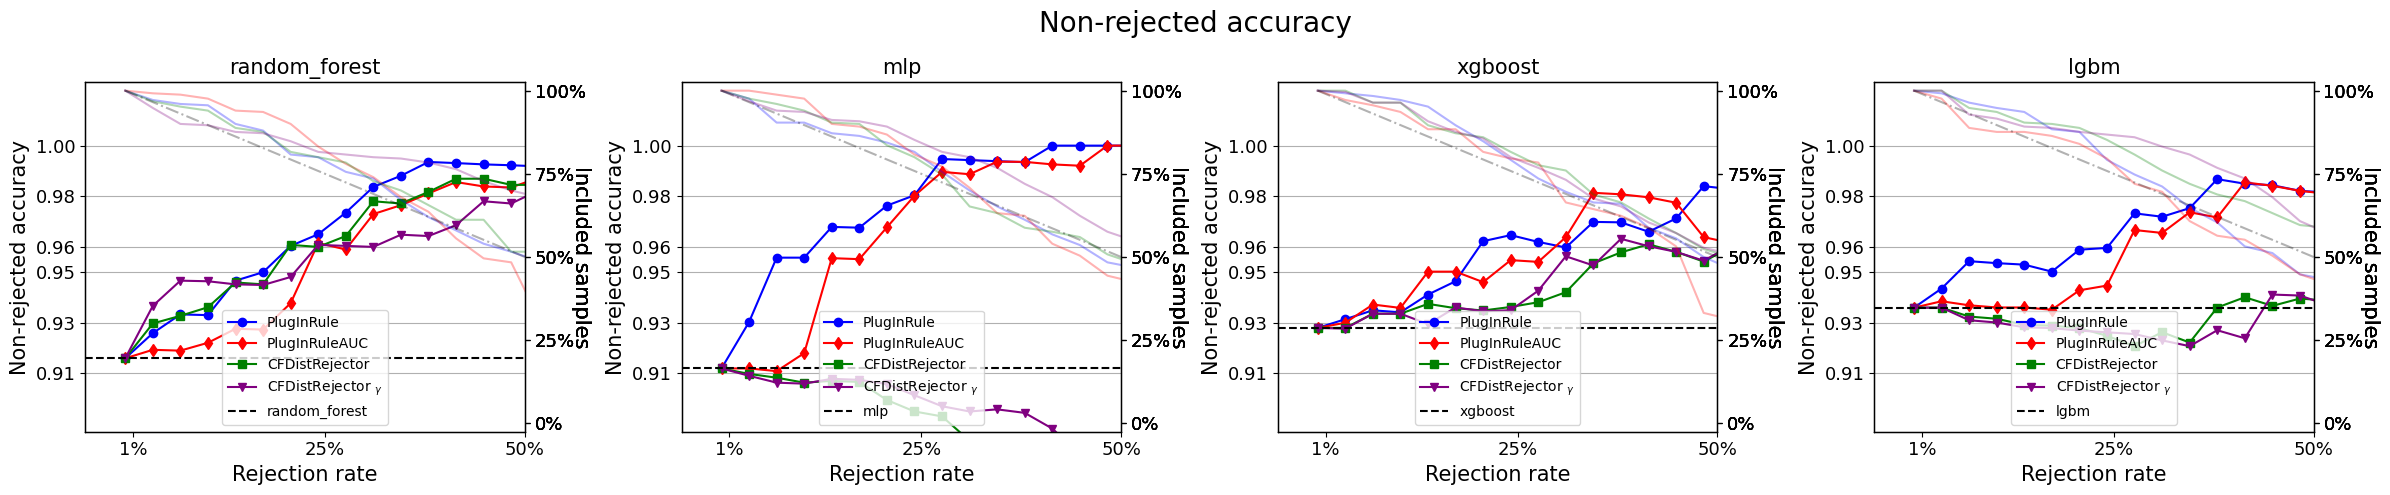

In [109]:
#iterate over the models

fig, ax = plt.subplots(1,#len(models.keys())//2,
                       len(models.keys()),
                       figsize=(24,5))
ax = ax.flatten()
for jj,k in enumerate(models.keys()):
    for selective_k,marker,color in zip(["PlugInRule","PlugInRuleAUC","CFDistRejector","CFDistRejector_gamma"],
                                        markers,
                                        colors):
        rejected_acc = rejected_by_coverage[k][selective_k]
        ax[jj].plot(np.arange(len(rejected_acc))/len(rejected_acc), rejected_acc, 
                    label=selective_k.replace("_gamma"," $_\gamma$"),
                    marker=marker,
                    color=color)

        ax[jj].set_title(k,fontsize=15)
        ax[jj].set_xlabel('Rejection rate', fontsize=15)
        # set the xticks to be 1%, 25 % , 50 %, 75 % and 99
        ax[jj].set_xticks([0.01,0.25,0.5,0.75,0.99])
        # add the percentage sign
        ax[jj].set_xticklabels(['1%','25%','50%','75%','99%'], fontsize=13)
        ax[jj].set_ylabel('Non-rejected accuracy', fontsize=15)
        ax[jj].grid()
        # plot the 0% rejection accuracy
        low_y_lim = -0.05
        low_y_lim = min(all_original_scores.values())
        ax[jj].set_ylim(low_y_lim-0.025,1.025)
        # get the ticks for the y axis of ax, and be sure to not exceed 1.0 as tick
        ax[jj].set_yticks(np.linspace(low_y_lim,1.0,6).round(2))
        # set the font of the y ticks
        ax[jj].yaxis.set_tick_params(labelsize=13)
        # get the twin axis
        axx2 = ax[jj].twinx()
        # plot the number of included samples in the classification
        included_samp = included_samples[k][selective_k]
        axx2.plot(np.arange(target_coverages_n)/target_coverages_n, included_samp, 
                    label="% samples",
                    
                    color=color,
                    linestyle="-",alpha=0.3)
        # to be ure add the "target" rejection rate as a diagonal line

        axx2.set_ylabel("Included samples",fontsize=15,rotation=270)
        axx2.set_ylim(-0.025,1.025)
        # set the yticks to be 0, 25 % , 50 %, 75 % and 100 %
        axx2.set_yticks([0,0.25,0.5,0.75,1])
        # add the percentage sign
        axx2.set_yticklabels(['0%','25%','50%','75%','100%'], fontsize=13)
        # place grid on the y axis
        ax[jj].grid()
        #axx2.legend(loc="lower right")
        ax[jj].set_xlim(-0.05,.5)
    ax[jj].axhline(all_original_scores[k],linestyle="--",
        color="black",label=k)
    axx2.plot([0,1],[1,0],color="black",linestyle="-.",alpha=0.3)
    ax[jj].legend(loc="lower center")
    # plot the y grid
    ax[jj].grid(axis='y')
plt.suptitle("Non-rejected accuracy",fontsize=20)
plt.tight_layout()
for k in models.keys():
    # roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    # print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(4)
    print(f"Model {k} Accuracy: {acc}")
plt.show()

Model random_forest Accuracy: 0.916
Model mlp Accuracy: 0.912
Model xgboost Accuracy: 0.928
Model lgbm Accuracy: 0.936


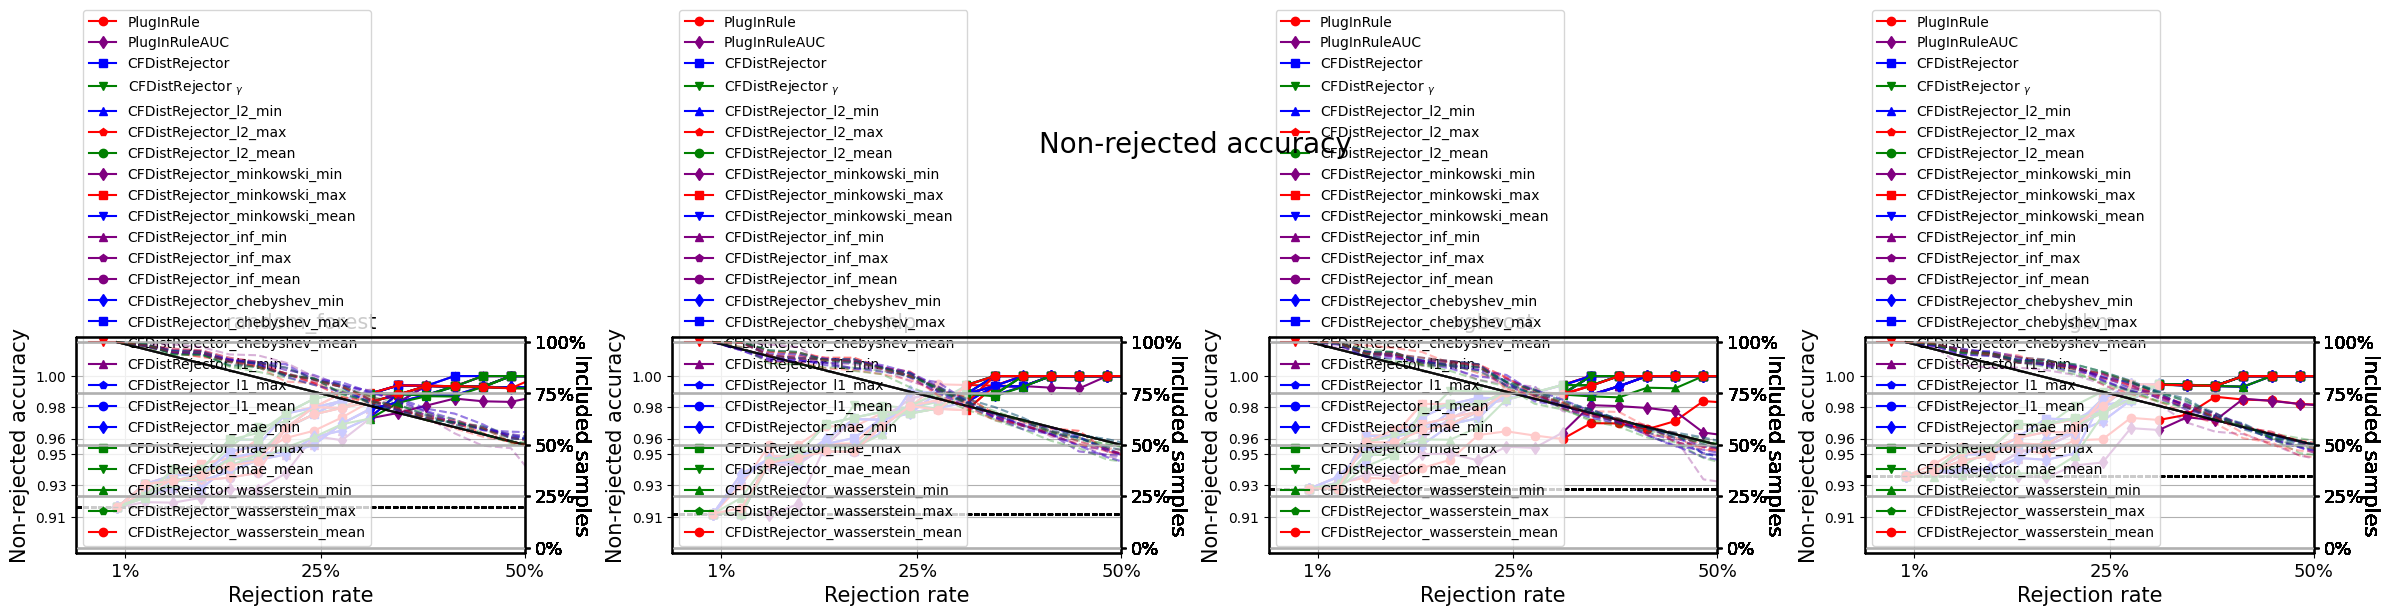

In [67]:
#iterate over the models

fig, ax = plt.subplots(1,#len(models.keys())//2,
                       len(models.keys()),
                       figsize=(24,5))
ax = ax.flatten()
for jj,k in enumerate(models.keys()):
    for selective_k,marker,color in zip(rejected_by_coverage[k].keys(),
                                        markers,
                                        colors):
        rejected_acc = rejected_by_coverage[k][selective_k]
        ax[jj].plot(np.arange(len(rejected_acc))/len(rejected_acc), rejected_acc, 
                    label=selective_k.replace("_gamma"," $_\gamma$"),
                    marker=marker,
                    color=color)

        ax[jj].legend(loc="lower left")
        ax[jj].set_title(k,fontsize=15)
        ax[jj].set_xlabel('Rejection rate', fontsize=15)
        # set the xticks to be 1%, 25 % , 50 %, 75 % and 99
        ax[jj].set_xticks([0.01,0.25,0.5,0.75,0.99])
        # add the percentage sign
        ax[jj].set_xticklabels(['1%','25%','50%','75%','99%'], fontsize=13)
        ax[jj].set_ylabel('Non-rejected accuracy', fontsize=15)
        ax[jj].grid()
        # plot the 0% rejection accuracy
        low_y_lim = -0.05
        low_y_lim = min(all_original_scores.values())
        ax[jj].set_ylim(low_y_lim-0.025,1.025)
        # get the ticks for the y axis of ax, and be sure to not exceed 1.0 as tick
        ax[jj].set_yticks(np.linspace(low_y_lim,1.0,6).round(2))
        
        #ax[jj].set_ylim(0.0,1.025)
        ax[jj].axhline(all_original_scores[k],linestyle="--",
        color="black",lw=1)
        # get the twin axis
        axx2 = ax[jj].twinx()
        # plot the number of included samples in the classification
        included_samp = included_samples[k][selective_k]
        axx2.plot(np.arange(target_coverages_n)/target_coverages_n, included_samp, 
                    label="% samples",
                    
                    color=color,
                    linestyle="--",alpha=0.3)
        # to be ure add the "target" rejection rate as a diagonal line
        axx2.plot([0,1],[1,0],color="black",linestyle="-",alpha=0.1)

        axx2.set_ylabel("Included samples",fontsize=15,rotation=270)
        axx2.set_ylim(-0.025,1.025)
        # set the yticks to be 0, 25 % , 50 %, 75 % and 100 %
        axx2.set_yticks([0,0.25,0.5,0.75,1])
        # add the percentage sign
        axx2.set_yticklabels(['0%','25%','50%','75%','100%'], fontsize=13)
        axx2.grid()
        #axx2.legend(loc="lower right")
        ax[jj].set_xlim(-0.05,.5)
plt.suptitle("Non-rejected accuracy",fontsize=20)
plt.tight_layout()
for k in models.keys():
    # roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    # print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(4)
    print(f"Model {k} Accuracy: {acc}")
plt.show()

In [203]:
import scikit_posthocs as sp
import scipy.stats as ss
from decimal import Decimal
def create_df_and_check(methods_names,
                        values,
                        title="",
                        title_size=18,
                        show=True,
                        exp="",
                        metrica='',
                        dt_name ='dt_name',vmin=0,vmax=0.4,hmargin=0.1,vertica_image_size=5):
    '''methods_names is a list of the names of the methods.
    values is a list containing the values of the methods. It has as many columns as the number of methods and as many rows as the number of metric domanins. For example if the metrics rre Frob and Kendalltau, the values will have 2 rows and as many rows as the number of proposals.'''
    # create the dataframe
    df = pd.DataFrame(values,columns=methods_names)
    # compute the ranks for the friedman test
    ranks = df.rank(axis=1)
    # check the shape of the ranks to be analogous to the methods_names
    assert ranks.values.shape[1] == len(methods_names), "the ranks have a different number of columns than the methods names"

    #print(ranks.shape,"shape of the ranks")
    #print(df.head())
    #print(ranks.head())
    
    # Convert p-value to scientific notation
    # now check the friedman test
    if len(values)>=3:
        _, p = ss.friedmanchisquare(*values)
        cd = sp.posthoc_nemenyi_friedman(ranks)
    else:
        raise("not enough values to perform the friedman test")
    if p < 0.05:
        #print("the differences are significant\n"+title)
        # prepare the CD diagram
        if  len(values)>=2:
            fig,ax = plt.subplots(2,1,figsize=(10,vertica_image_size))
            axes = ax.flatten()

            ranks_res,colors_res = remap_names(ranking_df=ranks,colors_dict=colors_dict)
            if (np.sum(cd<0.05)>0).any():
                # plot the CD diagram using the ranks and the critical difference
                cd.columns = [res_d[col] for col in cd.columns]
                # here it gives an error because the adjiance matrix is not symmetric
                # to solve this we need to make the adjiance matrix symmetric
                # the index of the adjiance matrix should be the same as the columns
                cd.index = cd.columns
                label_props = {"fontsize":title_size-1}
                print("plotting CD diagram")
                # all in black  
                black_colors = {k:"black" for k in colors_res.keys()}
                black_colors = colors_res
                axes[1].set_xlim(1,len(methods_names))
                # set the xlim to be in the 1-len(methods_names)-1 range
                # (there is never a first and last method that is significantly different)
                sp.critical_difference_diagram(ranks_res.T.mean(axis=1),cd,label_props=label_props,color_palette=black_colors,ax=axes[1],
                                               text_h_margin=hmargin)

            else:
                # now write big on the image "no significant difference"
                axes[1].text(0.5,0.5,"no significant difference",fontsize=20)
            # plot the boxplot of the values getting the pathces from the colors dictionary
            if metrica != "$ShapGap_{L2}$":
                values= -values
                df = -df
                if metrica != "Faithfulness":
                    ylab = "Similarity"
                
                else:
                    ylab = "Faithfulness"
            else:
                ylab = "Distance"
            
            axes[0].grid(axis='y')
            print("plotting boxplot")
            print(df)
            #for j in range(len(df.columns)):
            #    axes[0].scatter(j*np.ones(len(df)),df.iloc[:,j])
            #axes[0].boxplot(values,patch_artist=True,showfliers=True)
            sns.boxenplot(data=df,ax=axes[0],palette=[colors_dict[k] for k in df.columns],fill=False)

            '''
            pathches = axes[0].boxplot(values,patch_artist=True,showfliers=True)
            for pathch, mn in zip(pathches['boxes'],methods_names):
                c = colors[mn]
                
                pathch.set_facecolor(c)
            '''
            # set the xticks to be the names of the methods
            axes[0].set_xticks(np.arange(len(methods_names)),ranks_res.columns,rotation=30,fontsize=15)
            # set the title of the boxplot
            #axes[0].set_title("Boxplot of the values\n"+dt_name+" "+" ".join([str(elemento) for elemento in exp]),fontsize=title_size)
            # the y grid
            # set the y label
            axes[0].set_ylabel(ylab,fontsize=title_size)
            # set ylim
            #axes[0].set_ylim(vmin,vmax)

            
            p = np.sum(cd<0.05)
        print(cd.round(2))
        # remove the diagonal of the cd matrix as a new cd1 matrix
        cd1 = cd.copy()
        np.fill_diagonal(cd1.values,0)
        # do the sum
        s = np.sum(cd1.values,axis=1)
        print(s)
        # get the index of the lowest value that is lower than 0.05*len(methods_names)
        idx = np.where(s<0.05*len(methods_names))[0]
        print(s[idx])
        if len(idx)>0:
            p = min(s[idx])
        
            # transform the p value to scientific notation like 0.3E-3
            p_str = "{:.3E}".format(Decimal(str(p)))
            title += " - p value "+p_str
        else:
            title += " - No significant difference"

        plt.suptitle(title,fontsize=title_size)
        plt.tight_layout()
        
    print()

In [204]:
res_d = {k:k.replace("_"," ") for k in rejected_by_coverage["mlp"].keys()}
colors_dict = {k:colors[i] for i,k in enumerate(rejected_by_coverage["mlp"].keys())}

In [205]:
def remap_names(ranking_df,colors_dict):
    '''this function is used to remap the names of the methods to more meaningful names. It is used to plot the critical difference diagram.
    '''
    res_colors = {res_d[k]:v for k,v in colors_dict.items()}
    # rankin_df is a dataframe that has as many columns called as the methods 
    # to remap the names of the methods we use the res_d dictionary
    ranking_df.columns = [res_d[col] for col in ranking_df.columns]
    print(res_colors,"res_colors")
    print(ranking_df.columns,"columns of the ranking_df")
    return ranking_df,res_colors

{'PlugInRule': 'red', 'PlugInRuleAUC': 'purple', 'CFDistRejector': 'blue', 'CFDistRejector gamma': 'green', 'CFDistRejector l2 min': 'blue', 'CFDistRejector l2 max': 'red', 'CFDistRejector l2 mean': 'green', 'CFDistRejector minkowski min': 'purple', 'CFDistRejector minkowski max': 'red', 'CFDistRejector minkowski mean': 'blue', 'CFDistRejector inf min': 'purple', 'CFDistRejector inf max': 'purple', 'CFDistRejector inf mean': 'purple', 'CFDistRejector chebyshev min': 'blue', 'CFDistRejector chebyshev max': 'blue', 'CFDistRejector chebyshev mean': 'red', 'CFDistRejector l1 min': 'purple', 'CFDistRejector l1 max': 'blue', 'CFDistRejector l1 mean': 'blue', 'CFDistRejector mae min': 'blue', 'CFDistRejector mae max': 'green', 'CFDistRejector mae mean': 'green', 'CFDistRejector wasserstein min': 'green', 'CFDistRejector wasserstein max': 'green', 'CFDistRejector wasserstein mean': 'red'} res_colors
Index(['PlugInRule', 'PlugInRuleAUC', 'CFDistRejector', 'CFDistRejector gamma',
       'CFDistR

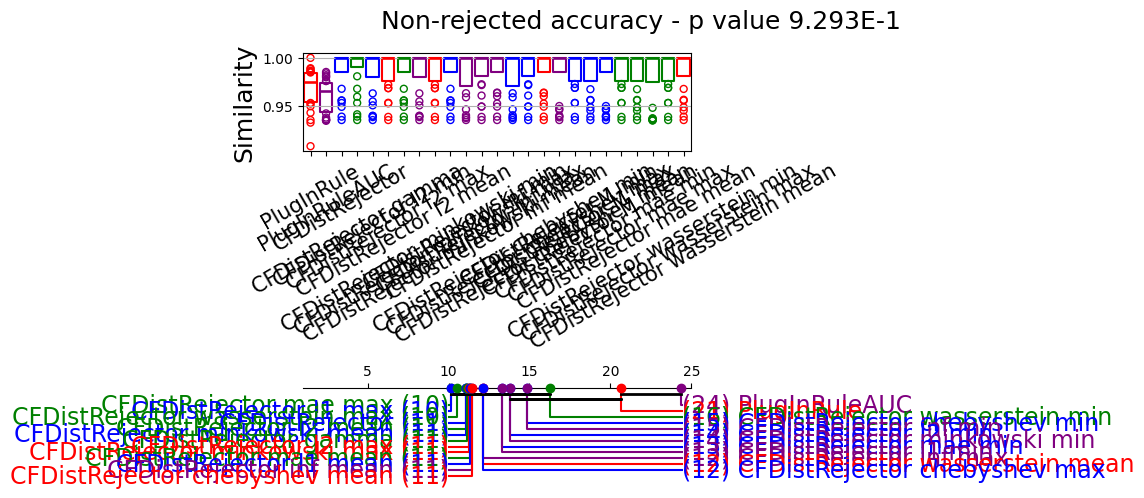

In [215]:
k = "lgbm"
#for j,m in enumerate(focus_metrics):
method_names = list(rejected_by_coverage[k].keys())#[4+j*3:4+6+(j+1)*3]
values = np.array([rejected_by_coverage[k][m] for m in method_names]).T

# now compute the statistical tests
create_df_and_check(methods_names=method_names,
                    values=-values,
                    title="Non-rejected accuracy",
                    show=True,
                    exp="",
                    metrica="Non-rejected accuracy",
                    dt_name = dt_name,
                    vmin=0.5,vmax=1,hmargin=0.1,vertica_image_size=5)
plt.show()

In [51]:
'''metric_specific = "l2"
dist_type = "mean"

for metric_specific in metrics:
    fig, axs = plt.subplots(1, 4, figsize=(10,3))
    axs = axs.flatten()
    for dist_type in ["min","max","mean"]:
        for j,k in enumerate(models.keys()):
            l2_rejector = cfdr.CFDistRejector(model=models[k],
                                            coverages=np.linspace(0.7,0.99,30))
            l2_rejector.deltas
            l2_rejector.calibrate(splits['X_calibration'], all_stats[k]["distances"][metric_specific][dist_type])      
            if dist_type =='mean':
                axs[j].plot(l2_rejector.deltas,label = f"{metric_specific}",ls =('--' if dist_type == "mean" else("-" if dist_type == "min" else ":")))
            else:
                axs[j].plot(l2_rejector.deltas)
            ax.set_title(k)
    plt.suptitle(name_dataset+" - "+metric_specific.upper(),fontsize=20)
    plt.tight_layout()
    plt.legend()
    # log scale the y axis
    #plt.yscale("log")
    plt.show()
    
'''

'metric_specific = "l2"\ndist_type = "mean"\n\nfor metric_specific in metrics:\n    fig, axs = plt.subplots(1, 4, figsize=(10,3))\n    axs = axs.flatten()\n    for dist_type in ["min","max","mean"]:\n        for j,k in enumerate(models.keys()):\n            l2_rejector = cfdr.CFDistRejector(model=models[k],\n                                            coverages=np.linspace(0.7,0.99,30))\n            l2_rejector.deltas\n            l2_rejector.calibrate(splits[\'X_calibration\'], all_stats[k]["distances"][metric_specific][dist_type])      \n            if dist_type ==\'mean\':\n                axs[j].plot(l2_rejector.deltas,label = f"{metric_specific}",ls =(\'--\' if dist_type == "mean" else("-" if dist_type == "min" else ":")))\n            else:\n                axs[j].plot(l2_rejector.deltas)\n            ax.set_title(k)\n    plt.suptitle(name_dataset+" - "+metric_specific.upper(),fontsize=20)\n    plt.tight_layout()\n    plt.legend()\n    # log scale the y axis\n    #plt.yscale("log

## End of official release

-o-o-o-o-o-

# EXPERIMENTAL PART
## Visualization
We will use a scatter plot to visualize the correlation between the distances and the probability output of the model.

In [36]:

# Example usage
class_labels = ["Class 0","Class 1"]

In [37]:
importlib.reload(fplt)

<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [38]:
# set monospace font for rc params
plt.rcParams['font.family'] = 'monospace'

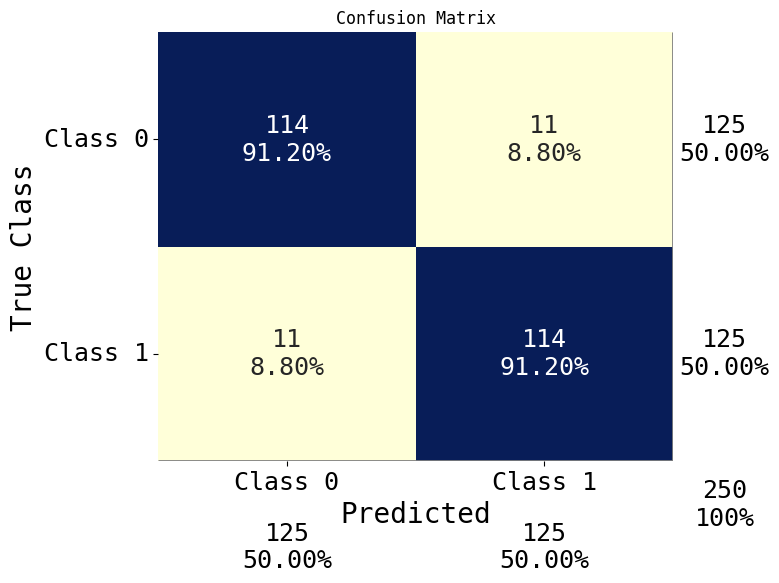

In [39]:
y_test = splits['y_test']
X_test = splits['X_test']
y_pred = models["mlp"].predict(X_test)

fplt.plot_confusion_matrix(y_test, y_pred, class_labels=class_labels,cmap='YlGnBu')

In [46]:
# now we do cool thing. We train a BernulliRBM to have a projection of the data in a two dimentional space (using the train split.)
# we then use the RBM to map 2d points to the original space and we plot the decision boundary of the original points but in the 2d space
# we then take few examples and we plot the counterfactuals in the 2d space. The few examples are the one with the smallest distance, the one with the largest distance, the one with a mid distance... 

from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class TrivialMapper():
    def __init__(self):
        pass
    def fit(self,X,y):
        pass
    def transform(self,X):
        return X
    def fit_transform(self,X,y):
        return X
    def inverse_transform(self,X):
        return X
    

mapper_ = Pipeline(steps=[
    ('scaler', models["random_forest"].named_steps['scaler']),
    ('mapper', TrivialMapper())#PCA(n_components=2)),#('rbm', BernoulliRBM(n_components=2, n_iter=100, random_state=0)),
    #('classifier', LogisticRegression(random_state=0))
])

mapper_.fit(splits['X_train'], splits['y_train'])

mapped_X = mapper_.transform(splits['X_test'])
mapped_X.shape

(250, 2)

In [47]:
class RBMInverseTransformer:
    def __init__(self, rbm):
        self.rbm = rbm

    def transform(self, X_transformed):
        """Approximate the inverse using RBM's weights and biases."""
        hidden_to_visible_weights = self.rbm.components_.T
        visible_bias = self.rbm.intercept_visible_

        # Perform the inverse transformation (logistic approximation)
        X_reconstructed = X_transformed @ hidden_to_visible_weights.T + visible_bias
        return X_reconstructed
    
inverse_mapper = Pipeline(steps=[
    ('imapper_', RBMInverseTransformer(mapper_.named_steps['mapper'])),
    #('inverse_scaler', mapper_rbm.named_steps['scaler'])
])

# Define the inverse PCA mapper
class InversePCAMapper:
    def __init__(self, scaler, pca):
        self.scaler = scaler
        self.pca = pca

    def transform(self, X_transformed):
        """
        Inverse the PCA transformation to map back to original scaled space.
        """
        # Inverse PCA to get back to scaled space
        X_scaled = self.pca.inverse_transform(X_transformed)
        # Inverse scaling to get back to the original space
        return self.scaler.inverse_transform(X_scaled)

inverse_pca = InversePCAMapper(scaler=mapper_.named_steps['scaler'], pca=mapper_.named_steps['mapper'])

inverse_mapper = inverse_pca



In [49]:
mapper_

Pipeline(steps=[('scaler', StandardScaler()),
                ('mapper', <__main__.TrivialMapper object at 0x7fa0f8d2fd90>)])

## How many mapped original points get classified in the same way to the original space points

In [48]:

_x_transformed = mapper_.transform(splits['X_train'])
_x_reconstructed = inverse_mapper.transform(_x_transformed)
_y_pred = models["random_forest"].predict(_x_reconstructed)
y_pred_train = models["random_forest"].predict(splits['X_train'])
print("Accuracy on the train",accuracy_score(_y_pred,y_pred_train))



Accuracy on the train 1.0


In [50]:
def load_cf(k):
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz")]
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)
    return cfs

In [51]:
X_train_2d = mapper_.transform(splits['X_train'])
X_cal_2d = mapper_.transform(splits['X_calibration'])
X_test_2d = mapper_.transform(splits['X_test'])


2025-02-02 23:51:34,080 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model random_forest using file cf_results_dice_kdtree_calibration_20250122_002604.npz
checking cf_results_dice_kdtree_calibration_20250122_002604.npz


2025-02-02 23:51:35,099 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model random_forest using file cf_results_dice_kdtree_test_20250122_171749.npz
checking cf_results_dice_kdtree_test_20250122_171749.npz


2025-02-02 23:51:39,056 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model mlp using file cf_results_dice_kdtree_calibration_20250122_022827.npz
checking cf_results_dice_kdtree_calibration_20250122_022827.npz


2025-02-02 23:51:40,013 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model mlp using file cf_results_dice_kdtree_test_20250122_200233.npz
checking cf_results_dice_kdtree_test_20250122_200233.npz


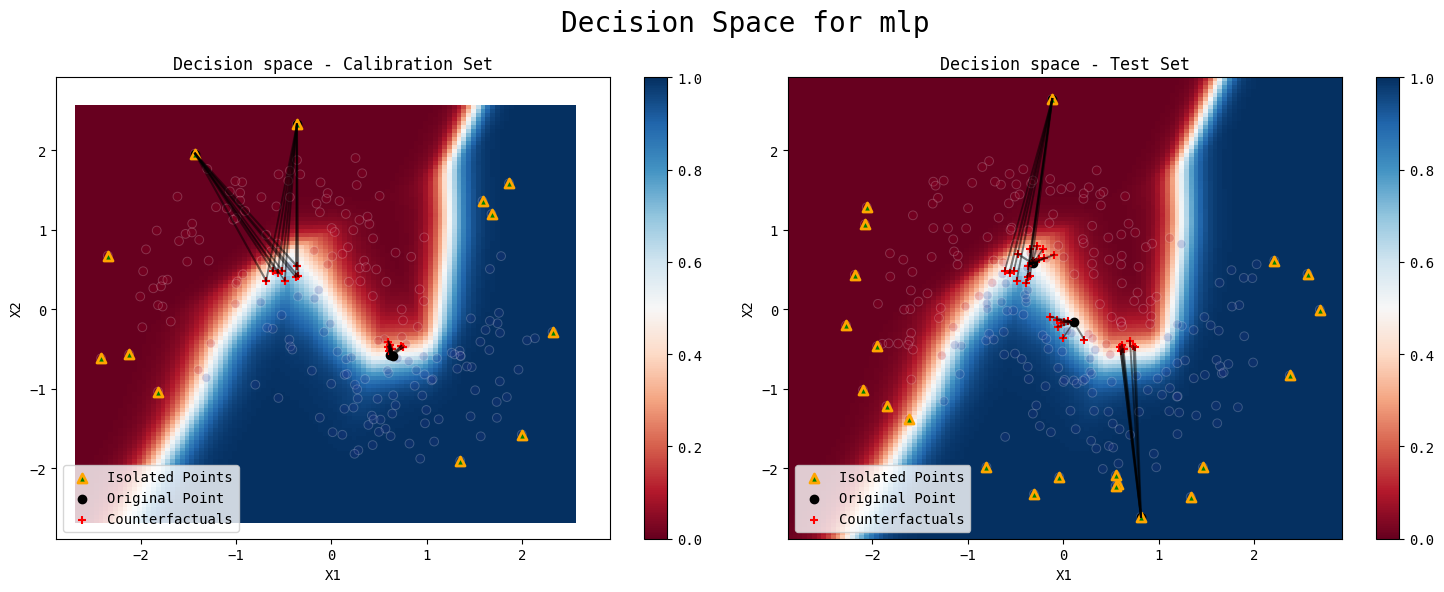

2025-02-02 23:51:44,323 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model xgboost using file cf_results_dice_kdtree_calibration_20250122_051630.npz
checking cf_results_dice_kdtree_calibration_20250122_051630.npz


2025-02-02 23:51:45,300 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model xgboost using file cf_results_dice_kdtree_test_20250123_014931.npz
checking cf_results_dice_kdtree_test_20250123_014931.npz


2025-02-02 23:51:49,048 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model lgbm using file cf_results_dice_kdtree_calibration_20250122_080758.npz
checking cf_results_dice_kdtree_calibration_20250122_080758.npz


2025-02-02 23:51:50,032 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model lgbm using file cf_results_dice_kdtree_test_20250123_074659.npz
checking cf_results_dice_kdtree_test_20250123_074659.npz


In [57]:

def plot_decision_space(my_model,model_name='',
                        draw_confidence=True,
                        X=None,y=None,
                        res = 0.1,
                        ax = None):
    """
        This funciton is used to plot the decision space of a model
    """
    x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
    y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
    x_max = y_max = max(x_max,y_max)
    y_min = x_min = min(x_min,y_min)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, res),
                            np.arange(y_min, y_max, res))

    if draw_confidence:
        Z = np.max(my_model.predict_proba(np.c_[xx.ravel(), yy.ravel()]),axis=1)
        cmap = plt.cm.YlGnBu    
    else:
        Z = my_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
        #cmap = plt.cm.RdYlBu.reversed()
        cmap = plt.cm.PiYG
        cmap = plt.cm.RdBu

    Z = Z.reshape(xx.shape)
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    vmax=1.0 if draw_confidence else float(len(set(y))-1)
    vmin=0.5 if draw_confidence else 0
    
    #plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap,
    #             vmin=vmin,vmax=vmax,
    #             levels=np.linspace(vmin,1.0,12))
    im = ax.pcolormesh(xx, yy, Z, cmap=cmap,vmin=vmin,vmax=vmax)
    
    plt.colorbar(im,ax=ax)
    # for the legend use the shaded color and the class labels: "predicted class i"
    #for i in range(0, len(set(y))):
    #    plt.scatter([], [], s=100, label="Class "+str(i),color=plt.cm.RdYlBu(i/len(set(y))),vmin=0,vmax=1)
    
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='white',
                linewidth=0.7,
                vmin=vmin,vmax=vmax,
                alpha=0.2,
                s=40)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.legend()
    if len(model_name)>0:
        model_name = ": "+str(model_name)
    ax.set_title('Decision Space of model'+str(model_name))
    return ax

cf_color = "red"
cf_marker = "+"
resol = 0.05

# the wrapper model takes as input the 2d points and returns the prediction of the model
# as the models in the models dictionary takes as input the original space, the initial step of the wrapper model is the inverse of the RBM
# the second step is the model itself
# inverse_rbm is the pipeline that takes the 2d points and returns the original space points
for k in models.keys():
    fig, axes = plt.subplots(1,2, figsize=(15, 6))
    axes = axes.flatten()
    wrapped_model = Pipeline(steps=[ # recreate now step by step the pipeline
        #("inverse_scaler", inverse_mapper.named_steps["scaler"]),
        ("inverse_mapper", inverse_mapper),
        #('scaler', models["mlp"].named_steps['scaler']),
        ('model', models[k].named_steps['model'])

    ])
    wrapped_model.predict(mapped_X)
    
    ax = plot_decision_space(wrapped_model,model_name=k,
                        X = X_cal_2d,y = wrapped_model.predict(X_cal_2d),
                        res=resol,
                        draw_confidence=False,
                        ax =axes[0])
    
    # select 10 random samples from the calibration set
    # plot the samples and the counterfactuals in the 2d space
    # for each sample plot a line that connects it with its counterfactuals
    # the line is colored by the distance of the counterfactuals 
    compute_test = False
    cfs = load_cf(k)
    # chosen samples are the 
    argsorted_idxs = all_stats[k]["distances"]["l2"]["mean"].argsort()
    # take one at the beginning, one at the end, one in the middle
    choosen_samples_ = argsorted_idxs[np.linspace(0,len(argsorted_idxs)-1,5).astype(int)]
    choosen_samples_ = argsorted_idxs[[0,1,len(argsorted_idxs)-2,len(argsorted_idxs)-1]]
    #twin_ax = ax.twiny()
    # plot the distances 
    #twin_ax.plot(all_stats[k]["distances"]["l2"]["mean"][argsorted_idxs],label="Mean Distance",color="black")
    #twin_ax.scatter(choosen_samples_,np.array(sorted(all_stats[k]["distances"]["l2"]["mean"].reshape(-1)))[choosen_samples_],color="red",label="Chosen Samples")
    for i in choosen_samples_:
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"].values
        original_class = cfs["cfs"][i]["true_class"]
        true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        
        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        good_cfs = good_cfs[true_cf != pred]
        true_cf = true_cf[true_cf != pred]
        if len (good_cfs) == 0:
            print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
            continue
            
        # plot the tranformed original point
        
        original_point = mapper_.transform(original_instance)[0]
        ax.scatter(original_point[0],original_point[1],color="black",marker="o")
        # plot the counterfactuals
        
        widths = all_stats[k]["distances"]["l2"]["mean"]
        widths = np.array(widths)
        widths = widths[widths != np.inf]
        widths = (widths-widths.min())/(widths.max()-widths.min())
        widths = (widths*0.5)+0.5
        for j in range(len(good_cfs)):
            cf = good_cfs[j]
            cf_point = mapper_.transform(cf.reshape(1,-1))[0]
            # plot the line connecting the two points
            # the width is proportional to the distance in the original space
            # the distance is the l2 norm

            ax.plot([original_point[0],cf_point[0]],[original_point[1],cf_point[1]],
                    lw=widths[j]*2,
                    alpha=0.5,color="black")
            # chose the color of the cf based on the class
            # the class is the opposite of the original class
            # plot the cf
        for j in range(len(good_cfs)):
            cf = good_cfs[j]
            cf_point = mapper_.transform(cf.reshape(1,-1))[0]
            ax.scatter(cf_point[0],cf_point[1],c=cf_color,marker=cf_marker)

    # plot some white x in correspondence of the anomalies
    ax.scatter(X_cal_2d[anomalies,0],X_cal_2d[anomalies,1], marker="^",label="Isolated Points",s=42,
               facecolors='green', edgecolors='orange', linewidths=2)
    
    # plot a single point for the legend
    ax.scatter([],[],color="black",marker="o",label="Original Point")
    ax.scatter([],[],color=cf_color,marker=cf_marker,label="Counterfactuals")
    
    ax.set_title("Decision space - Calibration Set")
    ax.legend(loc="lower left")










    compute_test = True


    ax = plot_decision_space(wrapped_model,model_name=k,
                        X = X_test_2d,y = wrapped_model.predict(X_test_2d),
                        res=resol,
                        draw_confidence=False,
                        ax=axes[1])

    cfs = load_cf(k)
    # chosen samples are the 
    argsorted_idxs = all_stats_test[k]["distances"]["l2"]["mean"].argsort()
    # take one at the beginning, one at the end, one in the middle
    choosen_samples_ = argsorted_idxs[np.linspace(0,len(argsorted_idxs)-1,5).astype(int)]
    choosen_samples_ = argsorted_idxs[[0,1,len(argsorted_idxs)-2,len(argsorted_idxs)-1]]
    cf_color = "red"
    cf_marker = "+"
    #twin_ax = ax.twiny()
    # plot the distances 
    #twin_ax.plot(all_stats[k]["distances"]["l2"]["mean"][argsorted_idxs],label="Mean Distance",color="black")
    #twin_ax.scatter(choosen_samples_,np.array(sorted(all_stats[k]["distances"]["l2"]["mean"].reshape(-1)))[choosen_samples_],color="red",label="Chosen Samples")
    for i in choosen_samples_:
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"].values
        original_class = cfs["cfs"][i]["true_class"]
        true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        
        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        good_cfs = good_cfs[true_cf != pred]
        true_cf = true_cf[true_cf != pred]
        if len (good_cfs) == 0:
            print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
            continue
            
        # plot the tranformed original point
        
        original_point = mapper_.transform(original_instance)[0]
        ax.scatter(original_point[0],original_point[1],color="black",marker="o")
        # plot the counterfactuals
        
        widths = all_stats[k]["distances"]["l2"]["mean"]
        widths = np.array(widths)
        widths = widths[widths != np.inf]
        widths = (widths-widths.min())/(widths.max()-widths.min())
        widths = (widths*0.5)+0.5
        for j in range(len(good_cfs)):
            cf = good_cfs[j]
            cf_point = mapper_.transform(cf.reshape(1,-1))[0]
            # plot the line connecting the two points
            # the width is proportional to the distance in the original space
            # the distance is the l2 norm

            ax.plot([original_point[0],cf_point[0]],[original_point[1],cf_point[1]],
                    lw=widths[j]*2,
                    alpha=0.5,color="black")
            # chose the color of the cf based on the class
            # the class is the opposite of the original class
            # plot the cf
        for j in range(len(good_cfs)):
            cf = good_cfs[j]
            cf_point = mapper_.transform(cf.reshape(1,-1))[0]
            ax.scatter(cf_point[0],cf_point[1],c=cf_color,marker=cf_marker)

    # plot some white x in correspondence of the anomalies
    ax.scatter(X_test_2d[anomalies_test,0],X_test_2d[anomalies_test,1],
                marker="^",label="Isolated Points",s=42,
               facecolors='green', edgecolors='orange', linewidths=2)

    # plot a single point for the legend
    ax.scatter([],[],color="black",marker="o",label="Original Point")
    ax.scatter([],[],color=cf_color,marker=cf_marker,label="Counterfactuals")
    
    ax.set_title("Decision space - Test Set")
    ax.legend(loc="lower left")
    















    

    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    for ax in axes:
        xlims = (min(xlims[0],ax.get_xlim()[0]),max(xlims[1],ax.get_xlim()[1]))
        ylims = (min(ylims[0],ax.get_ylim()[0]),max(ylims[1],ax.get_ylim()[1]))
    for ax in axes:
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
    plt.suptitle("Decision Space for "+k,fontsize=20)
    plt.tight_layout()



    fig_name = os.path.join("plots",dt_name,
                            "decision_space_"+k+".pdf")
    #plt.savefig(fig_name) # PNG is better
    plt.savefig(fig_name.replace(".pdf",".png"))
    plt.savefig(fig_name)
    if k=='mlp':
        plt.show()
    plt.close(fig)
    

In [82]:
print(f1_score(y_test, y_pred, average='weighted'))

0.912
